# ED2 M22 DMS Dataset — Exploratory Analysis

Goal: understand the mutation landscape to inform the design of simple generative baselines.

**WT CDRH3:** `HMSMQQVVSAGWERADLVGDAFDV` (24 residues)  
**WT M22 binding enrichment:** 5.190013461  
**Threshold for 'good':** log enrichment > WT value  
**Dataset:** ED2 — sequences with up to 2 mutations from WT (but includes ED1 as well)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# ── Constants ────────────────────────────────────────────────────────────────
DATA_PATH   = "/cluster/project/infk/krause/gguidarini/protein-design/data/raw/ED2_M22_binding_enrichment.csv"
SEQ_COL     = "aa"
METRIC_COL  = "M22_binding_enrichment_adj"
SE_COL      = "M22_binding_enrichment_se"
MUT_COL     = "mut"
NUM_MUT_COL = "num_mut"

WT_CDRH3    = "HMSMQQVVSAGWERADLVGDAFDV"
WT_FITNESS  = 5.190013461
CDRH3_LEN  = len(WT_CDRH3)  # 24
AA_ORDER    = list("ACDEFGHIKLMNPQRSTVWY")  # canonical 20 AAs

# Position labels (1-indexed for readability)
POS_LABELS = [f"{i+1}\n({aa})" for i, aa in enumerate(WT_CDRH3)]
POS_SHORT  = [f"{i+1}" for i in range(CDRH3_LEN)]

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})
print("Setup done.")

Setup done.


## 1. Load & Sanity Check

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (275354, 14)
Columns: ['aa', 'num_mut', 'mut', 'count_ED2M22pos', 'count_ED2M22neg', 'count_ED2pre', 'num_out_of_scope_muts', 'f_pos_r1', 'f_neg', 'f_pre', 'M22_enrichment_PosdivPre_adj', 'M22_binding_enrichment_adj', 'M22_binding_enrichment_se', 'M22_enrichment_PosdivPre_se']


,aa,num_mut,mut,count_ED2M22pos,count_ED2M22neg,count_ED2pre,num_out_of_scope_muts,f_pos_r1,f_neg,f_pre,M22_enrichment_PosdivPre_adj,M22_binding_enrichment_adj,M22_binding_enrichment_se,M22_enrichment_PosdivPre_se
0,AASMQQVRSAGWERADLVGDAFEV,4,H1A;M2A;V8R;D23E,0.0,14.0,0.0,0,0.000000,1.086942e-06,0.0,NaN,-5.430304,2.075158,NaN
1,AASMQQVVEAGWERADLVGDAFDV,3,H1A;M2A;S9E,23.0,0.0,0.0,0,0.000001,0.000000e+00,0.0,5.109968,4.982266,2.061870,2.061870
2,AASMQQVVSAGGERADLLGDAFDV,4,H1A;M2A;W12G;V18L,0.0,11.0,0.0,0,0.000000,8.540257e-07,0.0,NaN,-5.095884,2.084161,NaN
3,AASMQQVVSAGNERADLVGDAFDV,3,H1A;M2A;W12N,24.0,0.0,0.0,0,0.000001,0.000000e+00,0.0,5.170089,5.042387,2.060993,2.060993
4,AASMQQVVSAGWERADLVGDAFDI,3,H1A;M2A;V24I,21.0,0.0,0.0,0,0.000001,0.000000e+00,0.0,4.981644,4.853942,2.063867,2.063867


In [3]:
# Basic stats
print(f"Total sequences:      {len(df):,}")
print(f"Missing {METRIC_COL}: {df[METRIC_COL].isna().sum()}")
print(f"Missing {MUT_COL}:    {df[MUT_COL].isna().sum()}")
print()

# Edit distance distribution
ed_counts = df[NUM_MUT_COL].value_counts().sort_index()
print("Edit distance distribution:")
for ed, cnt in ed_counts.items():
    print(f"  ED{ed}: {cnt:,} sequences ({100*cnt/len(df):.1f}%)")

# Check if WT is in dataset
wt_rows = df[df[SEQ_COL] == WT_CDRH3]
print(f"\nWT rows in dataset: {len(wt_rows)}")
if len(wt_rows) > 0:
    print(wt_rows[[SEQ_COL, METRIC_COL]])

Total sequences:      275,354
Missing M22_binding_enrichment_adj: 0
Missing mut:    0

Edit distance distribution:
  ED0: 1 sequences (0.0%)
  ED1: 456 sequences (0.2%)
  ED2: 97,977 sequences (35.6%)
  ED3: 148,061 sequences (53.8%)
  ED4: 26,441 sequences (9.6%)
  ED5: 2,418 sequences (0.9%)

WT rows in dataset: 1
                              aa  M22_binding_enrichment_adj
155045  HMSMQQVVSAGWERADLVGDAFDV                    5.187325


In [4]:
# Parse mutation strings into structured form
# Format: "H1A;M2A" — semicolon-separated, 1-indexed positions

def parse_mutations(mut_str):
    """Parse mutation string like 'H1A;M2A' into list of (0-indexed pos, wt_aa, mut_aa)."""
    if pd.isna(mut_str) or mut_str == '':
        return []
    muts = []
    for m in str(mut_str).split(';'):
        m = m.strip()
        match = re.match(r'([A-Z])(\d+)([A-Z])', m)
        if match:
            wt_aa, pos_1, mut_aa = match.groups()
            muts.append((int(pos_1) - 1, wt_aa, mut_aa))  # 0-indexed
    return muts

df['parsed_muts'] = df[MUT_COL].apply(parse_mutations)

# Quick check on a few rows
print("Sample mutation parsing:")
print(df[[MUT_COL, 'parsed_muts']].head(10).to_string())

Sample mutation parsing:
                 mut                                     parsed_muts
0   H1A;M2A;V8R;D23E   [(0, H, A), (1, M, A), (7, V, R), (22, D, E)]
1        H1A;M2A;S9E               [(0, H, A), (1, M, A), (8, S, E)]
2  H1A;M2A;W12G;V18L  [(0, H, A), (1, M, A), (11, W, G), (17, V, L)]
3       H1A;M2A;W12N              [(0, H, A), (1, M, A), (11, W, N)]
4       H1A;M2A;V24I              [(0, H, A), (1, M, A), (23, V, I)]
5            H1A;M2A                          [(0, H, A), (1, M, A)]
6       H1A;M2A;D20R              [(0, H, A), (1, M, A), (19, D, R)]
7  H1A;M2A;E13H;A15R  [(0, H, A), (1, M, A), (12, E, H), (14, A, R)]
8            H1A;M2C                          [(0, H, A), (1, M, C)]
9  H1A;M2C;A21N;F22C  [(0, H, A), (1, M, C), (20, A, N), (21, F, C)]


## 2. Global Fitness Distribution

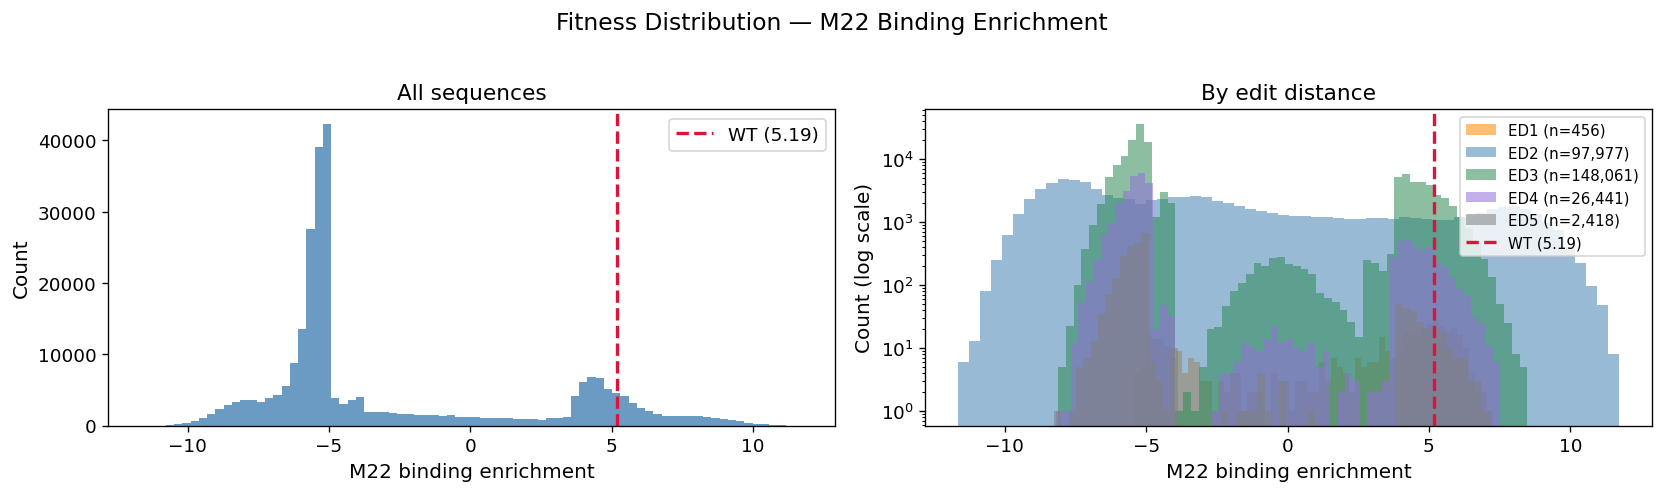

Fraction above WT: 0.100 (10.0%)
count    275354.000000
mean         -2.720584
std           4.855445
min         -11.643114
25%          -5.701606
50%          -5.095884
75%           0.830642
max          11.736301
Name: M22_binding_enrichment_adj, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# All sequences
ax = axes[0]
ax.hist(df[METRIC_COL].dropna(), bins=80, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(WT_FITNESS, color='crimson', lw=2, linestyle='--', label=f'WT ({WT_FITNESS:.2f})')
ax.set_xlabel('M22 binding enrichment')
ax.set_ylabel('Count')
ax.set_title('All sequences')
ax.legend()

# Separate by edit distance (log scale on y to see ED1 despite its small n)
ax = axes[1]
ed_palette = {1: 'darkorange', 2: 'steelblue', 3: 'seagreen', 4: 'mediumpurple', 5: 'gray'}
for ed in sorted(df[NUM_MUT_COL].unique()):
    if ed == 0:
        continue  # skip WT row
    sub = df[df[NUM_MUT_COL] == ed][METRIC_COL].dropna()
    color = ed_palette.get(ed, 'black')
    ax.hist(sub, bins=60, alpha=0.55, color=color, label=f'ED{ed} (n={len(sub):,})', edgecolor='none')
ax.axvline(WT_FITNESS, color='crimson', lw=2, linestyle='--', label=f'WT ({WT_FITNESS:.2f})')
ax.set_xlabel('M22 binding enrichment')
ax.set_ylabel('Count (log scale)')
ax.set_yscale('log')
ax.set_title('By edit distance')
ax.legend(fontsize=9)

plt.suptitle('Fitness Distribution — M22 Binding Enrichment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
above_wt = (df[METRIC_COL] > WT_FITNESS).mean()
print(f"Fraction above WT: {above_wt:.3f} ({100*above_wt:.1f}%)")
print(df[METRIC_COL].describe())

## 3. Single-Mutant Analysis (ED1 only)

ED1 sequences give us clean single-mutant effects — no additivity assumptions needed.

In [6]:
df_ed1 = df[df[NUM_MUT_COL] == 1].copy()
print(f"ED1 sequences: {len(df_ed1):,}")

# Extract (pos, mut_aa, fitness) for each ED1 row
ed1_records = []
for _, row in df_ed1.iterrows():
    muts = row['parsed_muts']
    if len(muts) == 1:
        pos, wt_aa, mut_aa = muts[0]
        ed1_records.append({
            'pos': pos,
            'wt_aa': wt_aa,
            'mut_aa': mut_aa,
            'fitness': row[METRIC_COL],
            'above_wt': row[METRIC_COL] > WT_FITNESS,
        })

df_ed1_flat = pd.DataFrame(ed1_records)
print(f"ED1 records parsed: {len(df_ed1_flat):,}")
print(f"Positions covered:  {df_ed1_flat['pos'].nunique()} / {CDRH3_LEN}")
print(f"Fraction above WT:  {df_ed1_flat['above_wt'].mean():.3f}")
df_ed1_flat.head()

ED1 sequences: 456
ED1 records parsed: 456
Positions covered:  24 / 24
Fraction above WT:  0.263


,pos,wt_aa,mut_aa,fitness,above_wt
0,0,H,A,3.415248,False
1,0,H,C,3.599310,False
2,0,H,D,-3.602463,False
3,0,H,E,-4.240046,False
4,0,H,F,-5.314814,False


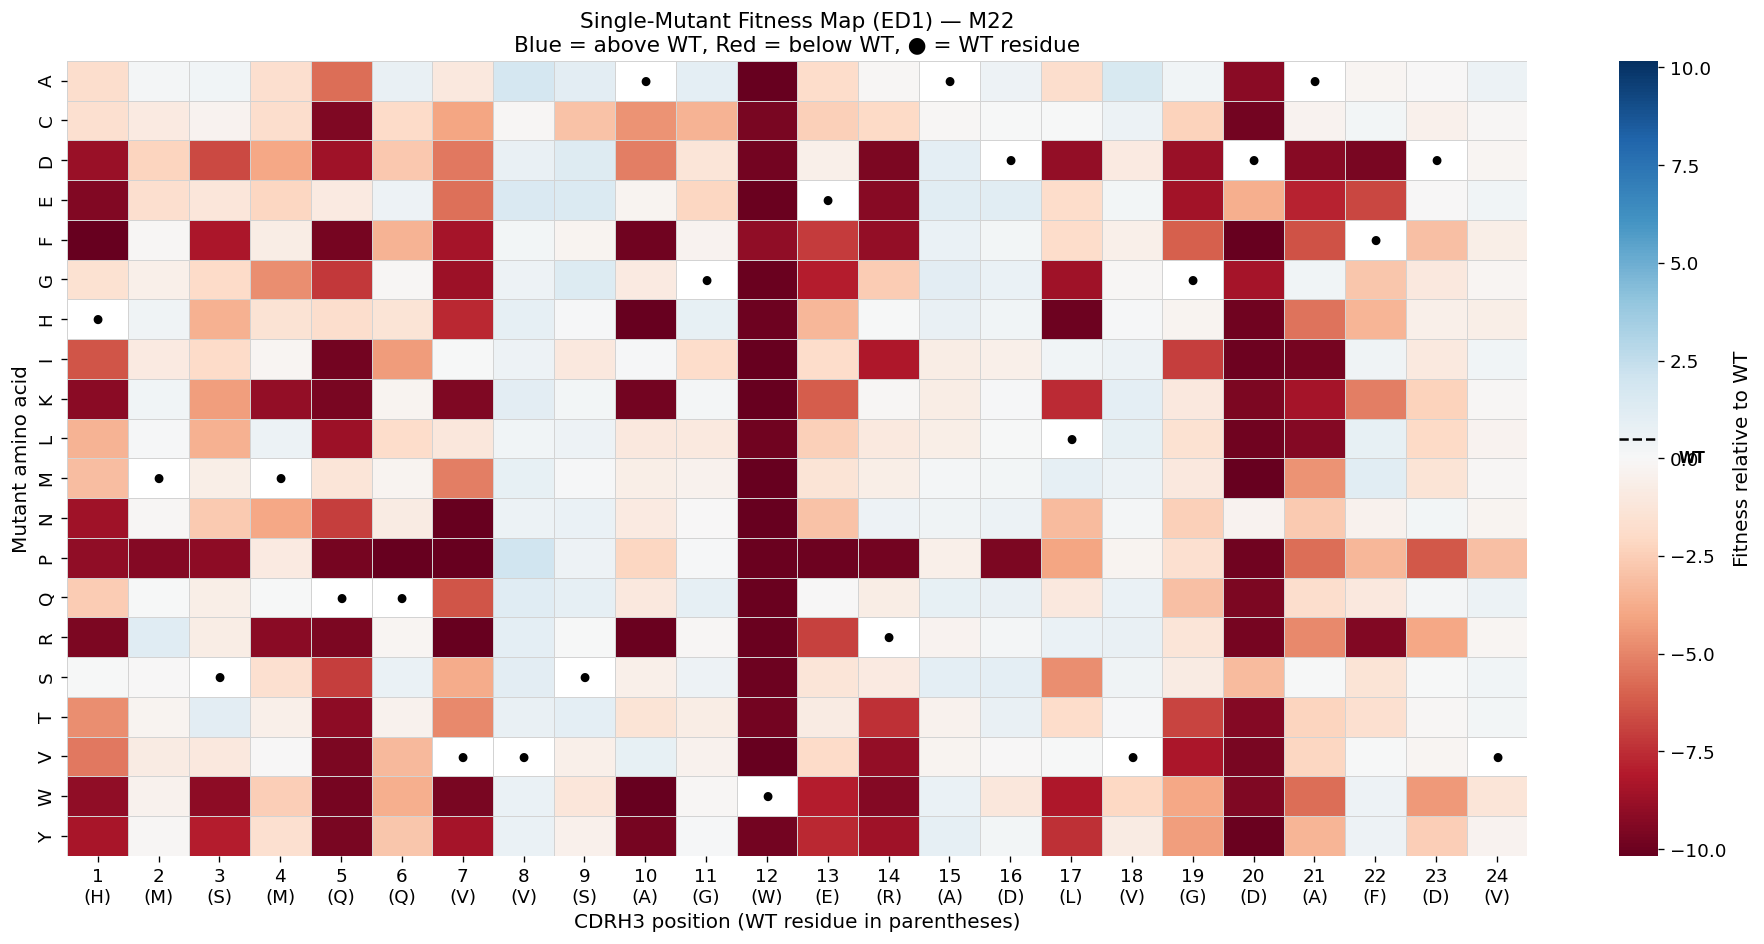

In [19]:
import matplotlib.colors as mcolors

# ── Relative fitness (deviation from WT) ─────────────────────────────────────
fitness_rel = fitness_matrix - WT_FITNESS

vmax_abs = max(
    abs(df_ed1_flat['fitness'].quantile(0.02) - WT_FITNESS),
    abs(df_ed1_flat['fitness'].quantile(0.98) - WT_FITNESS),
)

fig, ax = plt.subplots(figsize=(16, 8))
hm = sns.heatmap(
    fitness_rel.T,
    ax=ax,
    cmap='RdBu',        # red = worse, blue = better, white = WT-level
    center=0,
    vmin=-vmax_abs,
    vmax=+vmax_abs,     # symmetric around 0 so white = exactly WT
    linewidths=0.3,
    linecolor='lightgray',
    cbar_kws={'label': 'Fitness relative to WT'},
    xticklabels=POS_LABELS,
    yticklabels=AA_ORDER,
)

# WT dots
for i, aa in enumerate(WT_CDRH3):
    j = AA_ORDER.index(aa)
    ax.text(i + 0.5, j + 0.5, '●', ha='center', va='center', fontsize=7, color='black')

# WT marker on colorbar (always at center = 0)
cbar = hm.collections[0].colorbar
cbar.ax.axhline(y=0.5, color='black', linewidth=1.5, linestyle='--')
cbar.ax.text(1.5, 0.5, 'WT', va='center', ha='left',
             fontsize=9, fontweight='bold', transform=cbar.ax.transAxes)

ax.set_xlabel('CDRH3 position (WT residue in parentheses)')
ax.set_ylabel('Mutant amino acid')
ax.set_title('Single-Mutant Fitness Map (ED1) — M22\nBlue = above WT, Red = below WT, ● = WT residue')
plt.tight_layout()
plt.show()

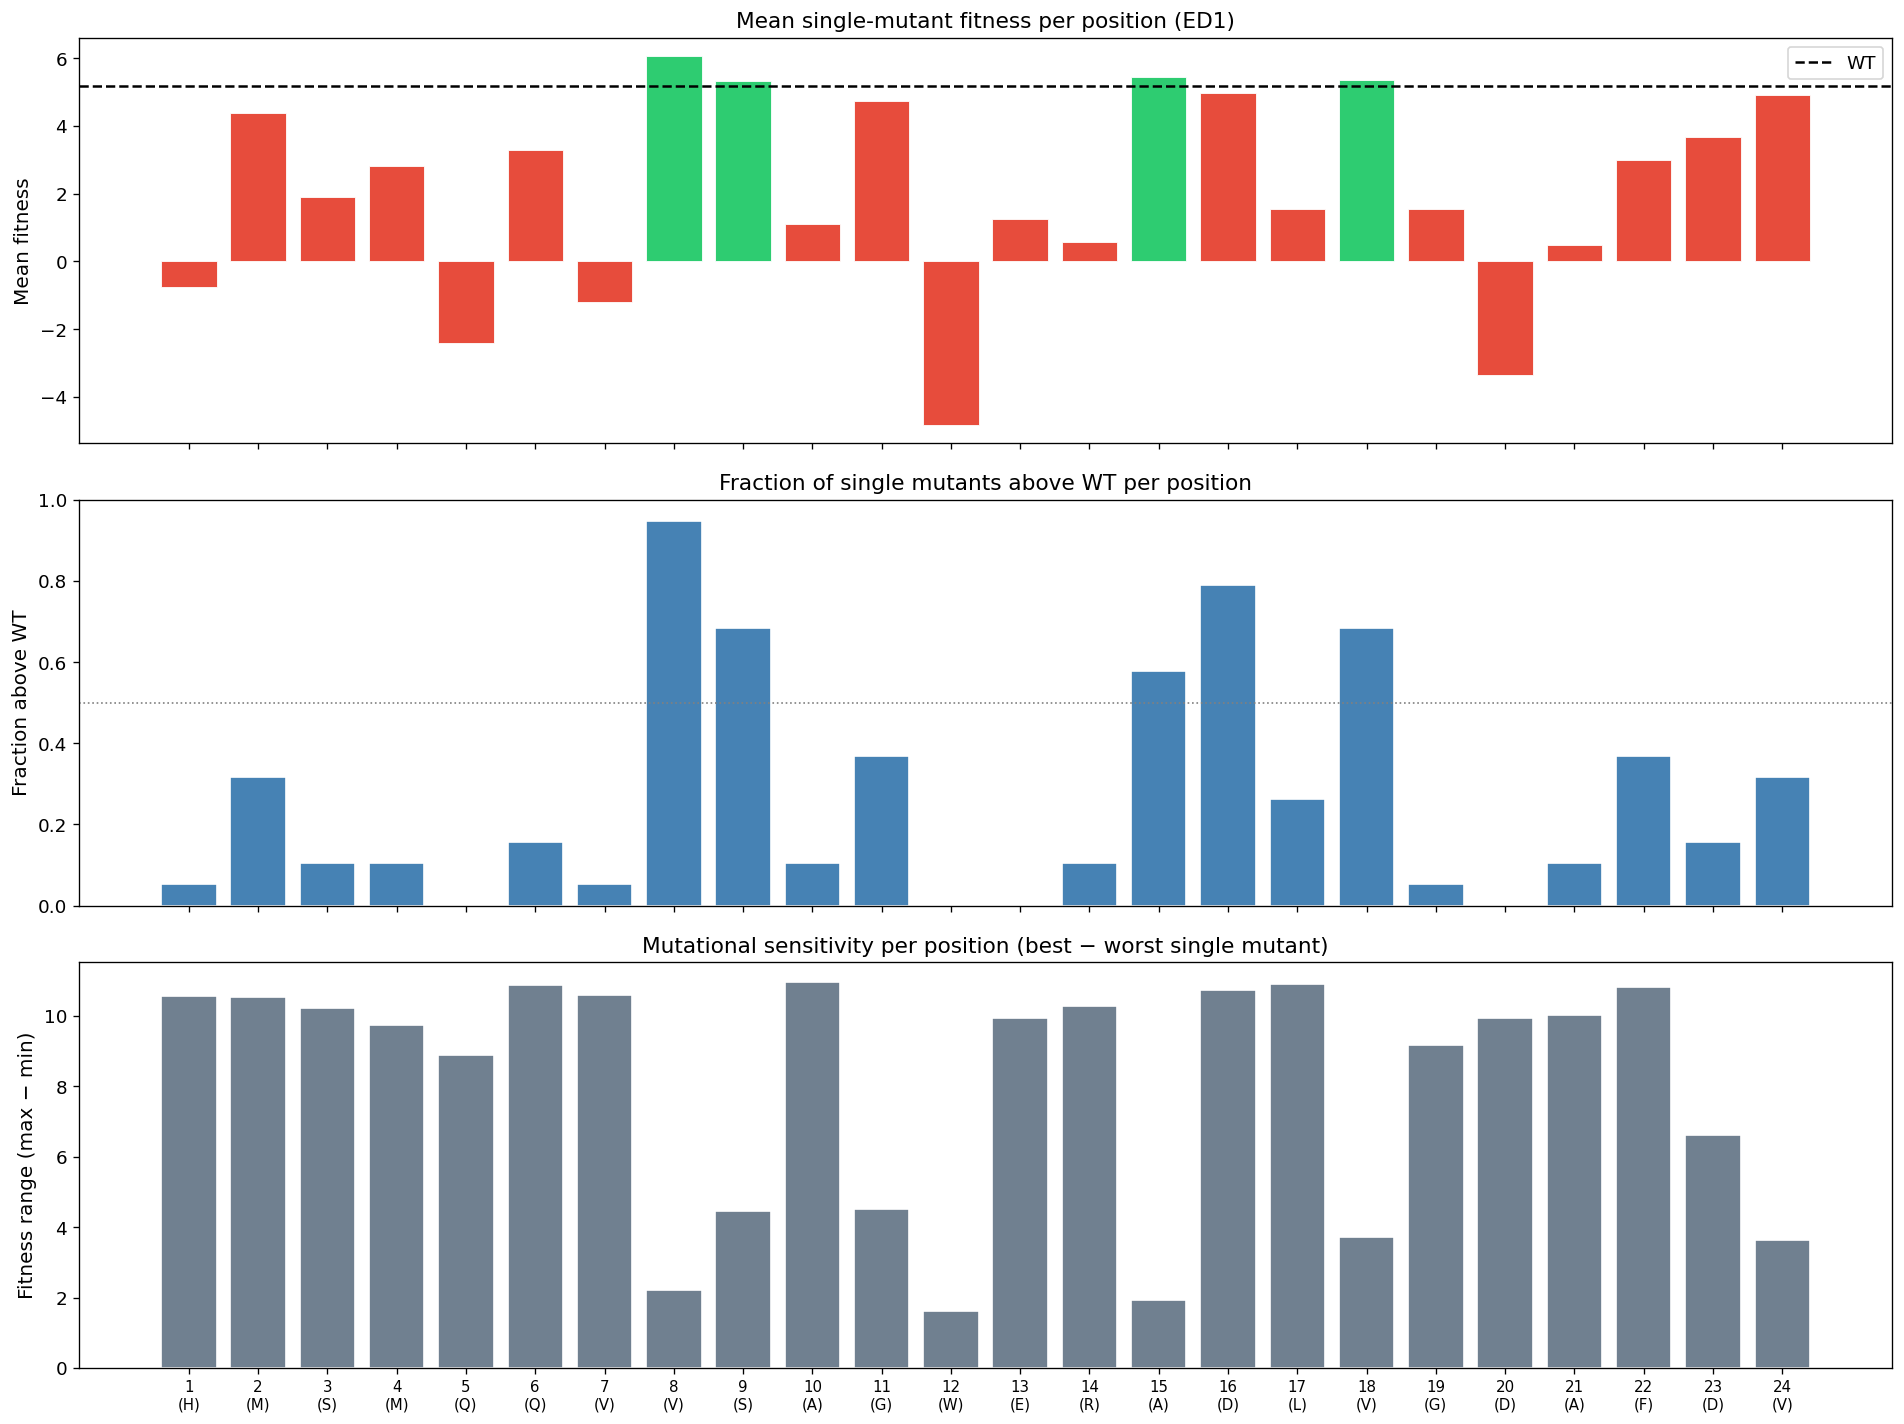


Top 5 positions by mean fitness (permissive — mutations generally beneficial):
 pos  mean_fitness  frac_above_wt  n_variants
   7      6.063489       0.947368          19
  14      5.440340       0.578947          19
  17      5.342190       0.684211          19
   8      5.339662       0.684211          19
  15      4.970819       0.789474          19

Top 5 positions by fraction above WT:
 pos  mean_fitness  frac_above_wt  n_variants
   7      6.063489       0.947368          19
  15      4.970819       0.789474          19
   8      5.339662       0.684211          19
  17      5.342190       0.684211          19
  14      5.440340       0.578947          19

Bottom 5 positions (mutations generally harmful):
 pos  mean_fitness  frac_above_wt  n_variants
  11     -4.819750       0.000000          19
  19     -3.354579       0.000000          19
   4     -2.404165       0.000000          19
   6     -1.187753       0.052632          19
   0     -0.766126       0.052632          19


In [20]:
# ── Per-position fitness summary (ED1) ───────────────────────────────────────
pos_stats_ed1 = df_ed1_flat.groupby('pos').agg(
    n_variants=('fitness', 'count'),
    mean_fitness=('fitness', 'mean'),
    median_fitness=('fitness', 'median'),
    std_fitness=('fitness', 'std'),       # spread of effects
    frac_above_wt=('above_wt', 'mean'),
    best_fitness=('fitness', 'max'),
    worst_fitness=('fitness', 'min'),
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Mean fitness per position
ax = axes[0]
colors = ['#2ecc71' if v > WT_FITNESS else '#e74c3c' for v in pos_stats_ed1['mean_fitness']]
ax.bar(pos_stats_ed1['pos'], pos_stats_ed1['mean_fitness'], color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(WT_FITNESS, color='black', lw=1.5, linestyle='--', label='WT')
ax.set_ylabel('Mean fitness')
ax.set_title('Mean single-mutant fitness per position (ED1)')
ax.legend()

# Fraction above WT per position
ax = axes[1]
ax.bar(pos_stats_ed1['pos'], pos_stats_ed1['frac_above_wt'], color='steelblue', edgecolor='white')
ax.axhline(0.5, color='gray', lw=1, linestyle=':')
ax.set_ylabel('Fraction above WT')
ax.set_title('Fraction of single mutants above WT per position')
ax.set_ylim(0, 1)

# Number of variants observed per position
ax = axes[2]
fitness_range = pos_stats_ed1['best_fitness'] - pos_stats_ed1['worst_fitness']
ax.bar(pos_stats_ed1['pos'], fitness_range, color='slategray', edgecolor='white')
ax.set_ylabel('Fitness range (max − min)')
ax.set_title('Mutational sensitivity per position (best − worst single mutant)')

# Add WT residue labels on x-axis
for ax in axes:
    ax.set_xticks(range(CDRH3_LEN))
    ax.set_xticklabels(POS_LABELS, fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 positions by mean fitness (permissive — mutations generally beneficial):")
print(pos_stats_ed1.nlargest(5, 'mean_fitness')[['pos', 'mean_fitness', 'frac_above_wt', 'n_variants']].to_string(index=False))
print("\nTop 5 positions by fraction above WT:")
print(pos_stats_ed1.nlargest(5, 'frac_above_wt')[['pos', 'mean_fitness', 'frac_above_wt', 'n_variants']].to_string(index=False))
print("\nBottom 5 positions (mutations generally harmful):")
print(pos_stats_ed1.nsmallest(5, 'mean_fitness')[['pos', 'mean_fitness', 'frac_above_wt', 'n_variants']].to_string(index=False))

In [9]:
# ── Best single mutations (for use in baselines) ──────────────────────────────
top_single_muts = df_ed1_flat[df_ed1_flat['above_wt']].sort_values('fitness', ascending=False)
print(f"Single mutations above WT: {len(top_single_muts)} / {len(df_ed1_flat)}")
print(f"\nTop 20 single mutations:")
display_cols = ['pos', 'wt_aa', 'mut_aa', 'fitness']
print(top_single_muts[display_cols].head(20).to_string(index=False))

Single mutations above WT: 120 / 456

Top 20 single mutations:
 pos wt_aa mut_aa  fitness
   7     V      P 7.254119
   7     V      A 7.014238
  17     V      A 6.839072
   7     V      E 6.706891
   8     S      E 6.696253
   8     S      G 6.549619
   8     S      D 6.474300
   7     V      Q 6.455669
   1     M      R 6.411182
  21     F      M 6.368614
  15     D      E 6.365717
  14     A      E 6.325583
   7     V      K 6.302293
  14     A      G 6.296322
   2     S      T 6.292865
   7     V      S 6.272599
   8     S      A 6.266550
  14     A      D 6.203494
  14     A      S 6.198086
   8     S      T 6.182584


## 4. Mutation Frequency Analysis (all ED1+ED2)

Which positions and substitutions appear most often in the dataset?

Total mutation events: 758,447


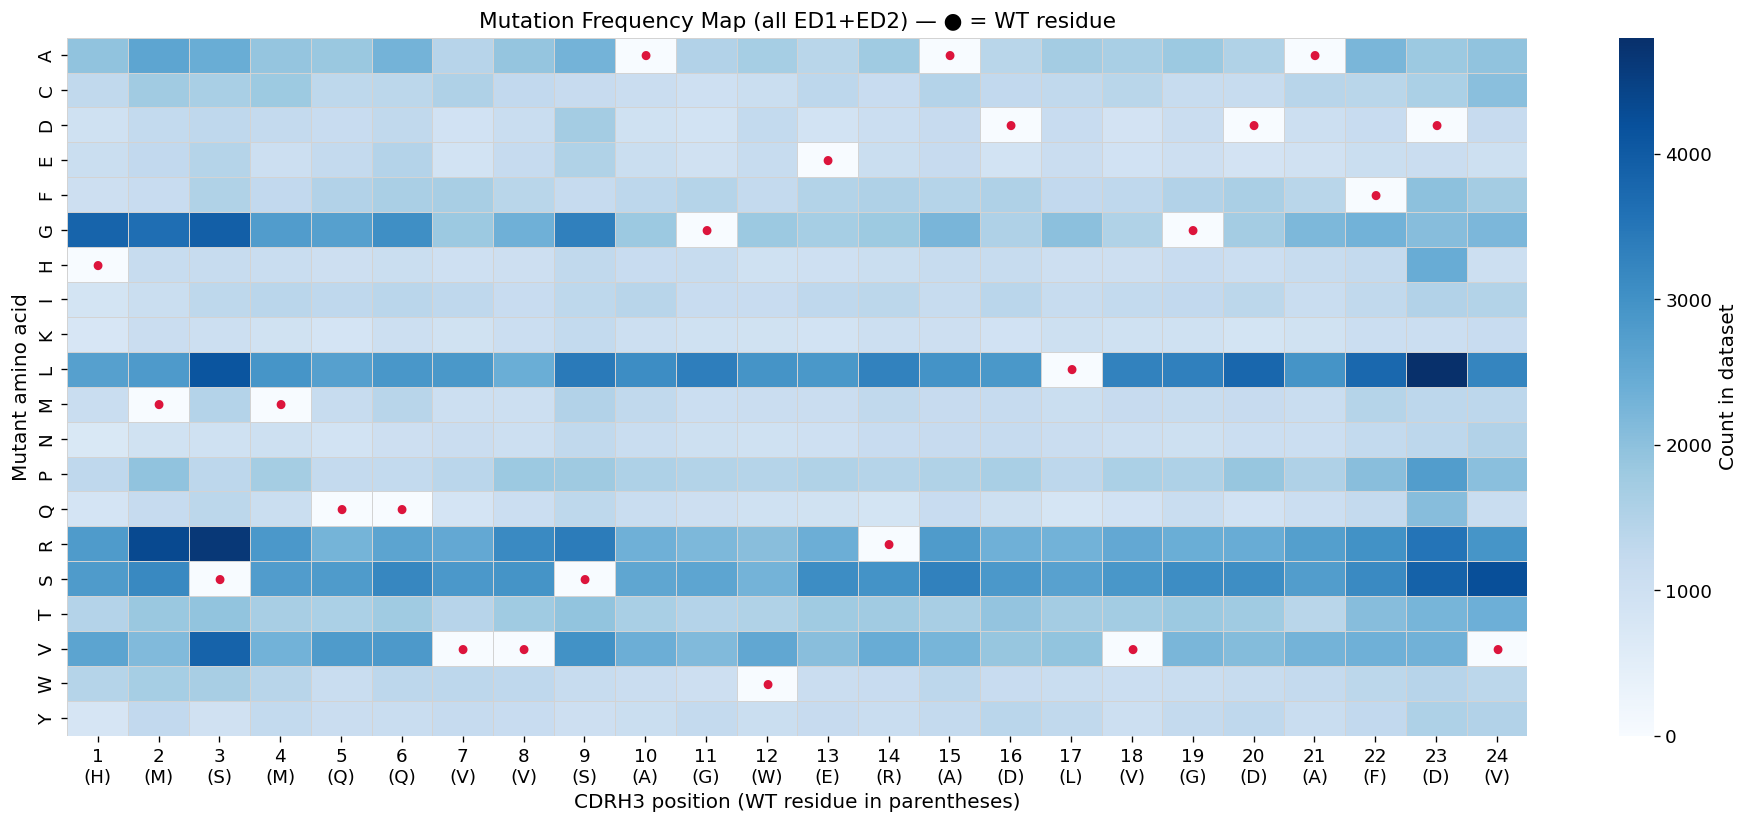

In [10]:
# Explode all mutations into a flat table
all_mut_records = []
for _, row in df.iterrows():
    for (pos, wt_aa, mut_aa) in row['parsed_muts']:
        all_mut_records.append({
            'pos': pos,
            'wt_aa': wt_aa,
            'mut_aa': mut_aa,
            'fitness': row[METRIC_COL],
            'above_wt': row[METRIC_COL] > WT_FITNESS,
            'num_mut': row[NUM_MUT_COL],
        })

df_muts = pd.DataFrame(all_mut_records)
print(f"Total mutation events: {len(df_muts):,}")

# Frequency heatmap — how many times does each (pos, AA) appear in dataset
freq_matrix = pd.DataFrame(0, index=range(CDRH3_LEN), columns=AA_ORDER)
for _, row in df_muts.iterrows():
    if row['mut_aa'] in AA_ORDER:
        freq_matrix.loc[row['pos'], row['mut_aa']] += 1

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    freq_matrix.T,
    ax=ax,
    cmap='Blues',
    linewidths=0.3,
    linecolor='lightgray',
    cbar_kws={'label': 'Count in dataset'},
    xticklabels=POS_LABELS,
    yticklabels=AA_ORDER,
)
for i, aa in enumerate(WT_CDRH3):
    j = AA_ORDER.index(aa)
    ax.text(i + 0.5, j + 0.5, '●', ha='center', va='center', fontsize=7, color='crimson')

ax.set_xlabel('CDRH3 position (WT residue in parentheses)')
ax.set_ylabel('Mutant amino acid')
ax.set_title('Mutation Frequency Map (all ED1+ED2) — ● = WT residue')
plt.tight_layout()
plt.show()

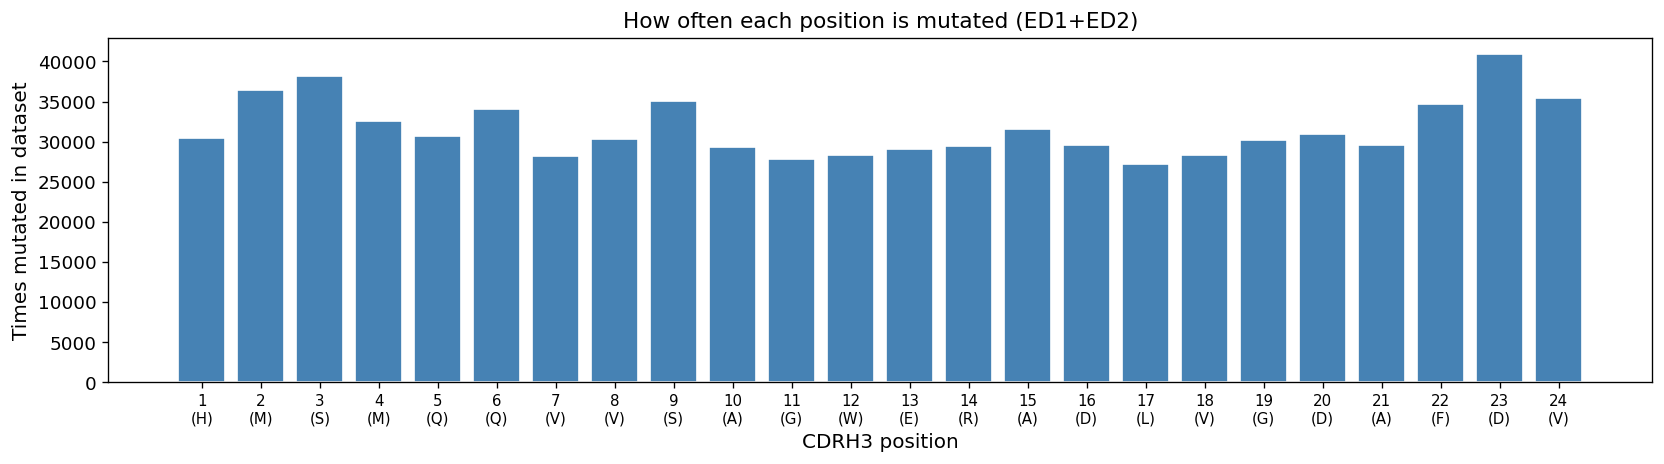

In [11]:
# ── Marginal position frequency ───────────────────────────────────────────────
pos_freq = df_muts['pos'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(pos_freq.index, pos_freq.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(CDRH3_LEN))
ax.set_xticklabels(POS_LABELS, fontsize=9)
ax.set_xlabel('CDRH3 position')
ax.set_ylabel('Times mutated in dataset')
ax.set_title('How often each position is mutated (ED1+ED2)')
plt.tight_layout()
plt.show()

## 5. Co-mutation Analysis (ED2 pairs)

Which pairs of positions are mutated together? Are some pairs enriched or depleted?

ED2 sequences: 97,977


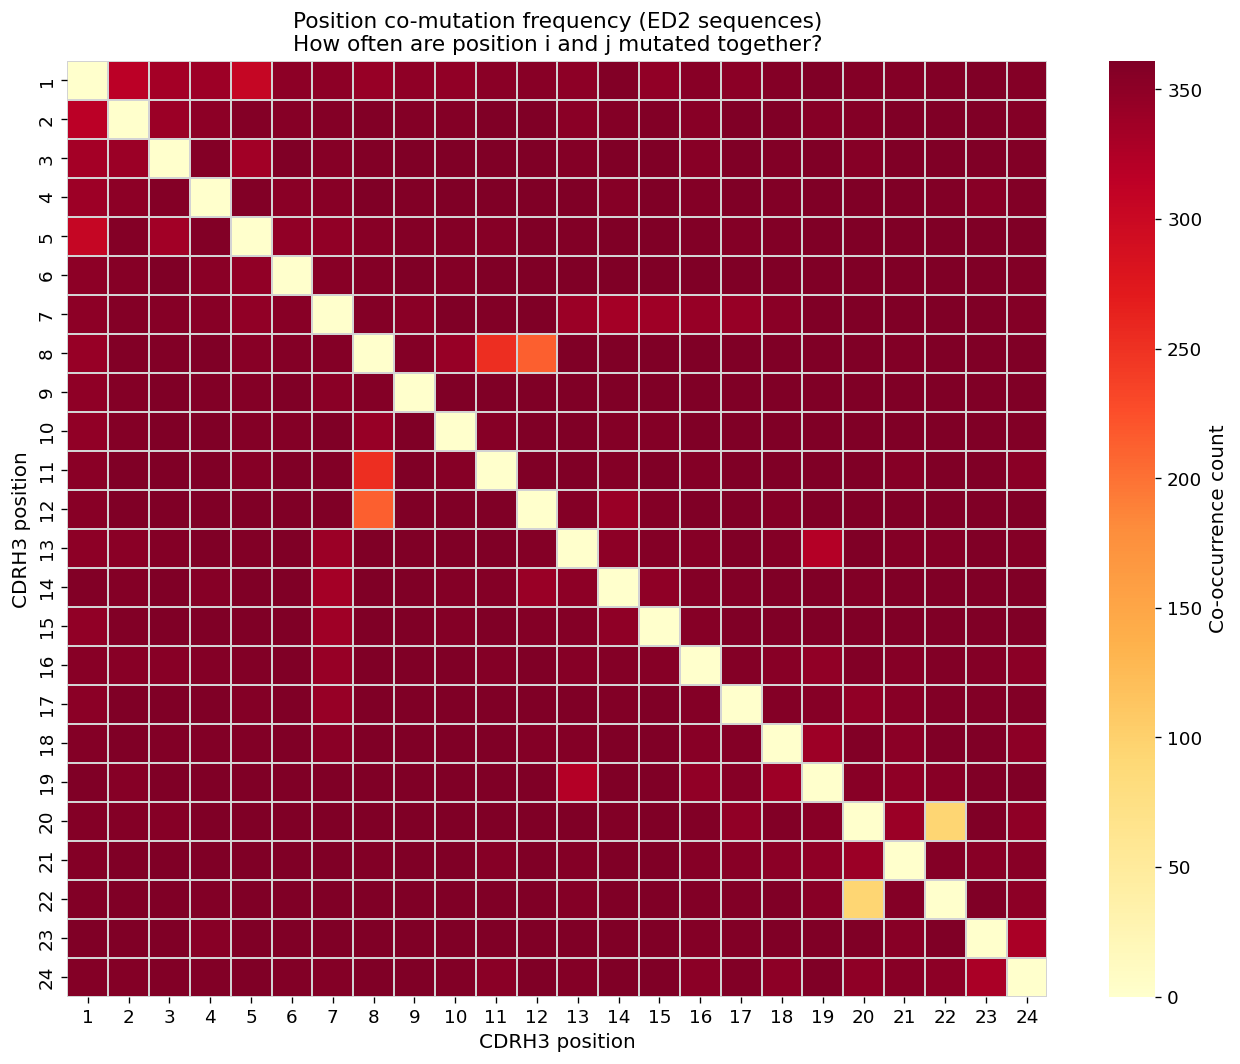


Top 15 co-occurring position pairs:
 pos1  pos2  count
   14    22    361
   14    20    361
   14    19    361
   13    23    361
   13    22    361
   13    21    361
   13    20    361
   13    18    361
    0    22    361
    0    18    361
   11    22    361
   11    21    361
   11    20    361
   11    19    361
   11    18    361


In [ ]:
df_ed2 = df[df[NUM_MUT_COL] == 2].copy()
print(f"ED2 sequences: {len(df_ed2):,}")

# Co-occurrence matrix: how often are position i and j mutated together
cooccur = np.zeros((CDRH3_LEN, CDRH3_LEN), dtype=int)
for _, row in df_ed2.iterrows():
    muts = row['parsed_muts']
    if len(muts) == 2:
        p1, p2 = muts[0][0], muts[1][0]
        cooccur[p1, p2] += 1
        cooccur[p2, p1] += 1

# Mask diagonal
np.fill_diagonal(cooccur, 0)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cooccur,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.2,
    linecolor='lightgray',
    cbar_kws={'label': 'Co-occurrence count'},
    xticklabels=POS_SHORT,
    yticklabels=POS_SHORT,
)
ax.set_title('Position co-mutation frequency (ED2 sequences)\nHow often are position i and j mutated together?')
ax.set_xlabel('CDRH3 position')
ax.set_ylabel('CDRH3 position')
plt.tight_layout()
plt.show()

# Top co-occurring pairs
pairs = []
for i in range(CDRH3_LEN):
    for j in range(i+1, CDRH3_LEN):
        if cooccur[i, j] > 0:
            pairs.append((i, j, cooccur[i, j]))
pairs_df = pd.DataFrame(pairs, columns=['pos1', 'pos2', 'count']).sort_values('count', ascending=False)
print("\nTop 15 co-occurring position pairs:")
print(pairs_df.head(15).to_string(index=False))

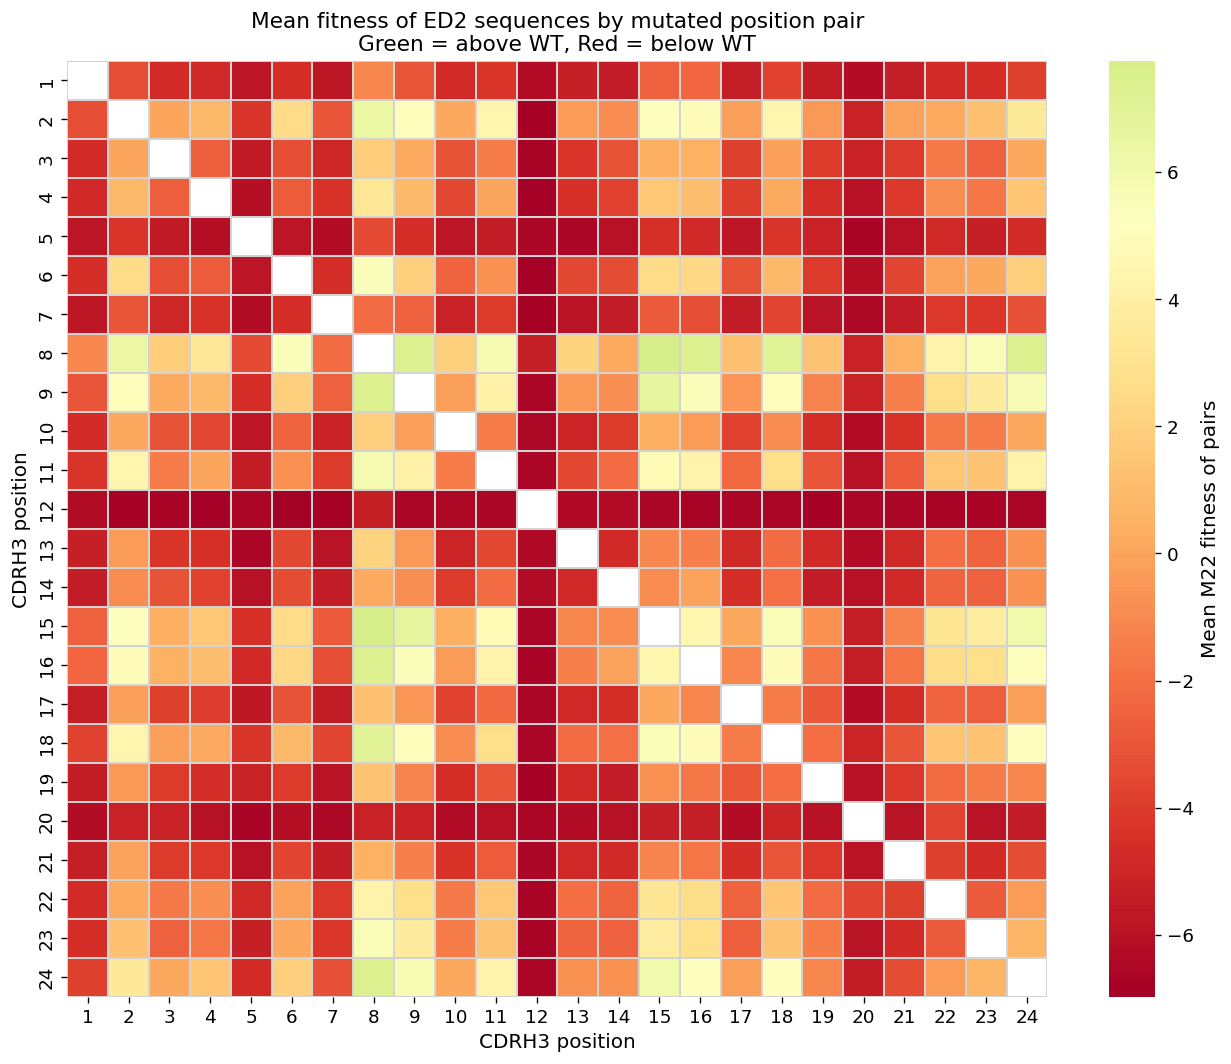

In [13]:
# ── Mean fitness of ED2 pairs by position pair ────────────────────────────────
fitness_pairs = np.full((CDRH3_LEN, CDRH3_LEN), np.nan)
count_pairs   = np.zeros((CDRH3_LEN, CDRH3_LEN), dtype=int)

for _, row in df_ed2.iterrows():
    muts = row['parsed_muts']
    if len(muts) == 2 and not np.isnan(row[METRIC_COL]):
        p1, p2 = muts[0][0], muts[1][0]
        for p_a, p_b in [(p1, p2), (p2, p1)]:
            if np.isnan(fitness_pairs[p_a, p_b]):
                fitness_pairs[p_a, p_b] = row[METRIC_COL]
            else:
                fitness_pairs[p_a, p_b] = (fitness_pairs[p_a, p_b] * count_pairs[p_a, p_b] + row[METRIC_COL]) / (count_pairs[p_a, p_b] + 1)
            count_pairs[p_a, p_b] += 1

np.fill_diagonal(fitness_pairs, np.nan)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    fitness_pairs,
    ax=ax,
    cmap='RdYlGn',
    center=WT_FITNESS,
    linewidths=0.2,
    linecolor='lightgray',
    cbar_kws={'label': 'Mean M22 fitness of pairs'},
    xticklabels=POS_SHORT,
    yticklabels=POS_SHORT,
)
ax.set_title('Mean fitness of ED2 sequences by mutated position pair\nGreen = above WT, Red = below WT')
ax.set_xlabel('CDRH3 position')
ax.set_ylabel('CDRH3 position')
plt.tight_layout()
plt.show()

Possible ED2 combinations:  99,636  (C(24,2)×19² = 99,636)
Unique ED2 combos in data:  97,977  (rows: 97,977)
Missing:                    1,659  (1.67% absent)
Coverage:                   98.33%

Position pairs with incomplete coverage: 194 / 276


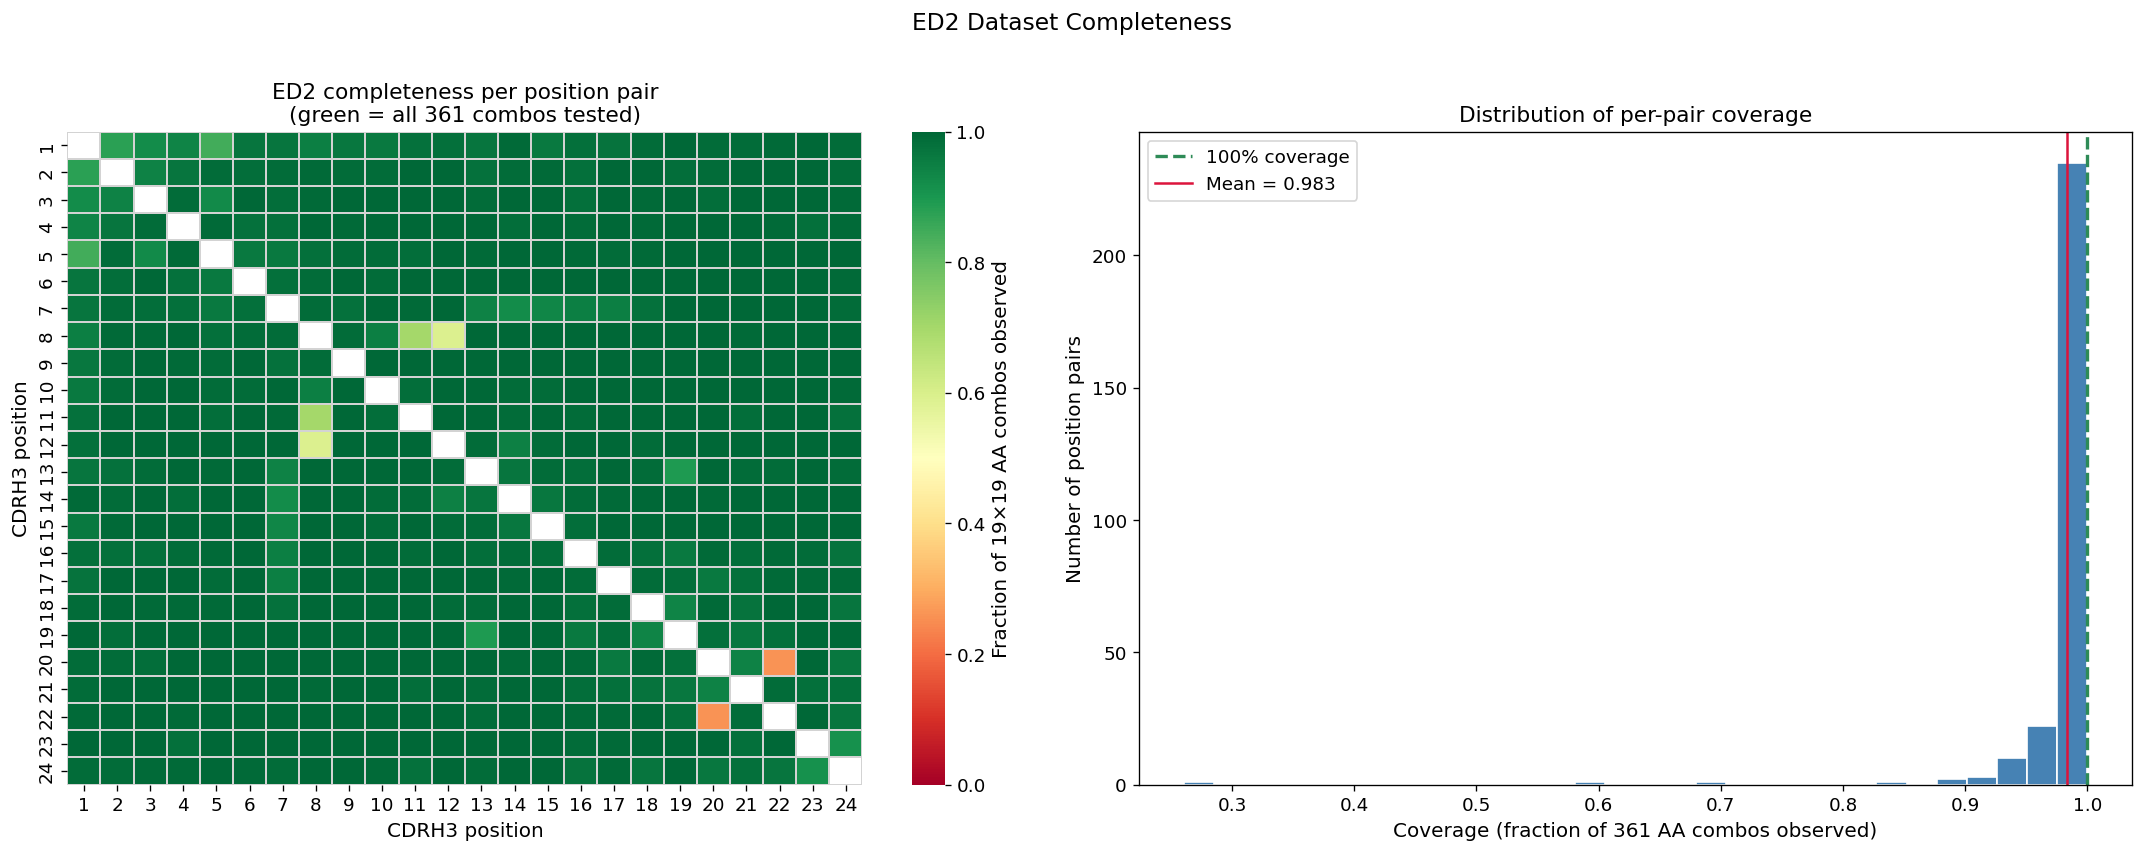


Worst-covered position pairs:
 p1  p2  observed  missing  coverage
 19  21        94      267  0.260388
  7  11       214      147  0.592798
  7  10       253      108  0.700831
  0   4       305       56  0.844875
  0   1       317       44  0.878116
 12  18       322       39  0.891967
 22  23       329       32  0.911357
  6  13       333       28  0.922438
  0   2       334       27  0.925208
  2   4       335       26  0.927978
  6  14       338       23  0.936288
  0   3       339       22  0.939058
 17  18       339       22  0.939058
  1   2       340       21  0.941828
  6  12       340       21  0.941828


In [24]:
from collections import Counter

# ── All possible ED2 combinations: C(24,2) position pairs × 19×19 AA combos ──
# (each position mutated to any AA except its own WT)
all_possible_ed2 = set()
for p1 in range(CDRH3_LEN):
    for p2 in range(p1 + 1, CDRH3_LEN):
        wt1, wt2 = WT_CDRH3[p1], WT_CDRH3[p2]
        for aa1 in AA_ORDER:
            if aa1 == wt1:
                continue
            for aa2 in AA_ORDER:
                if aa2 == wt2:
                    continue
                all_possible_ed2.add((p1, aa1, p2, aa2))

n_possible = len(all_possible_ed2)
print(f"Possible ED2 combinations:  {n_possible:,}  (C(24,2)×19² = {276*361:,})")

# ── Observed ED2 combinations (canonical: p1 < p2) ───────────────────────────
observed_ed2 = set()
for _, row in df_ed2.iterrows():
    muts = row['parsed_muts']
    if len(muts) != 2:
        continue
    (p1, _, aa1), (p2, _, aa2) = muts[0], muts[1]
    if p1 > p2:
        p1, aa1, p2, aa2 = p2, aa2, p1, aa1
    observed_ed2.add((p1, aa1, p2, aa2))

missing_ed2 = all_possible_ed2 - observed_ed2

print(f"Unique ED2 combos in data:  {len(observed_ed2):,}  (rows: {len(df_ed2):,})")
print(f"Missing:                    {len(missing_ed2):,}  ({100*len(missing_ed2)/n_possible:.2f}% absent)")
print(f"Coverage:                   {100*len(observed_ed2)/n_possible:.2f}%")

# ── Per position-pair coverage ────────────────────────────────────────────────
pair_obs = Counter((p1, p2) for (p1, _, p2, _) in observed_ed2)
n_aa_combos = 19 * 19  # 361 per pair

pair_rows = []
for p1 in range(CDRH3_LEN):
    for p2 in range(p1 + 1, CDRH3_LEN):
        obs = pair_obs.get((p1, p2), 0)
        pair_rows.append({'p1': p1, 'p2': p2, 'observed': obs,
                          'missing': n_aa_combos - obs,
                          'coverage': obs / n_aa_combos})
pair_df = pd.DataFrame(pair_rows)

n_incomplete = (pair_df['coverage'] < 1.0).sum()
print(f"\nPosition pairs with incomplete coverage: {n_incomplete} / {len(pair_df)}")

# Heatmap
cov_matrix = np.full((CDRH3_LEN, CDRH3_LEN), np.nan)
for _, r in pair_df.iterrows():
    cov_matrix[int(r.p1), int(r.p2)] = r.coverage
    cov_matrix[int(r.p2), int(r.p1)] = r.coverage

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
im = sns.heatmap(
    cov_matrix,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.2, linecolor='lightgray',
    xticklabels=POS_SHORT, yticklabels=POS_SHORT,
    cbar_kws={'label': 'Fraction of 19×19 AA combos observed'},
)
ax.set_title('ED2 completeness per position pair\n(green = all 361 combos tested)')
ax.set_xlabel('CDRH3 position')
ax.set_ylabel('CDRH3 position')

# Coverage distribution across pairs
ax = axes[1]
ax.hist(pair_df['coverage'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(1.0, color='seagreen', lw=2, linestyle='--', label='100% coverage')
ax.axvline(pair_df['coverage'].mean(), color='crimson', lw=1.5,
           label=f"Mean = {pair_df['coverage'].mean():.3f}")
ax.set_xlabel('Coverage (fraction of 361 AA combos observed)')
ax.set_ylabel('Number of position pairs')
ax.set_title('Distribution of per-pair coverage')
ax.legend()

plt.suptitle('ED2 Dataset Completeness', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

if n_incomplete > 0:
    print("\nWorst-covered position pairs:")
    print(pair_df.nsmallest(15, 'coverage')[['p1', 'p2', 'observed', 'missing', 'coverage']].to_string(index=False))
else:
    print("\nAll position pairs have 100% AA combination coverage.")

## 6. Epistasis Estimation

For ED2 sequences where both individual mutants exist in ED1, compare observed fitness vs. additive expectation.

ED2 sequences with both singles in ED1: 97,977 / 97,977


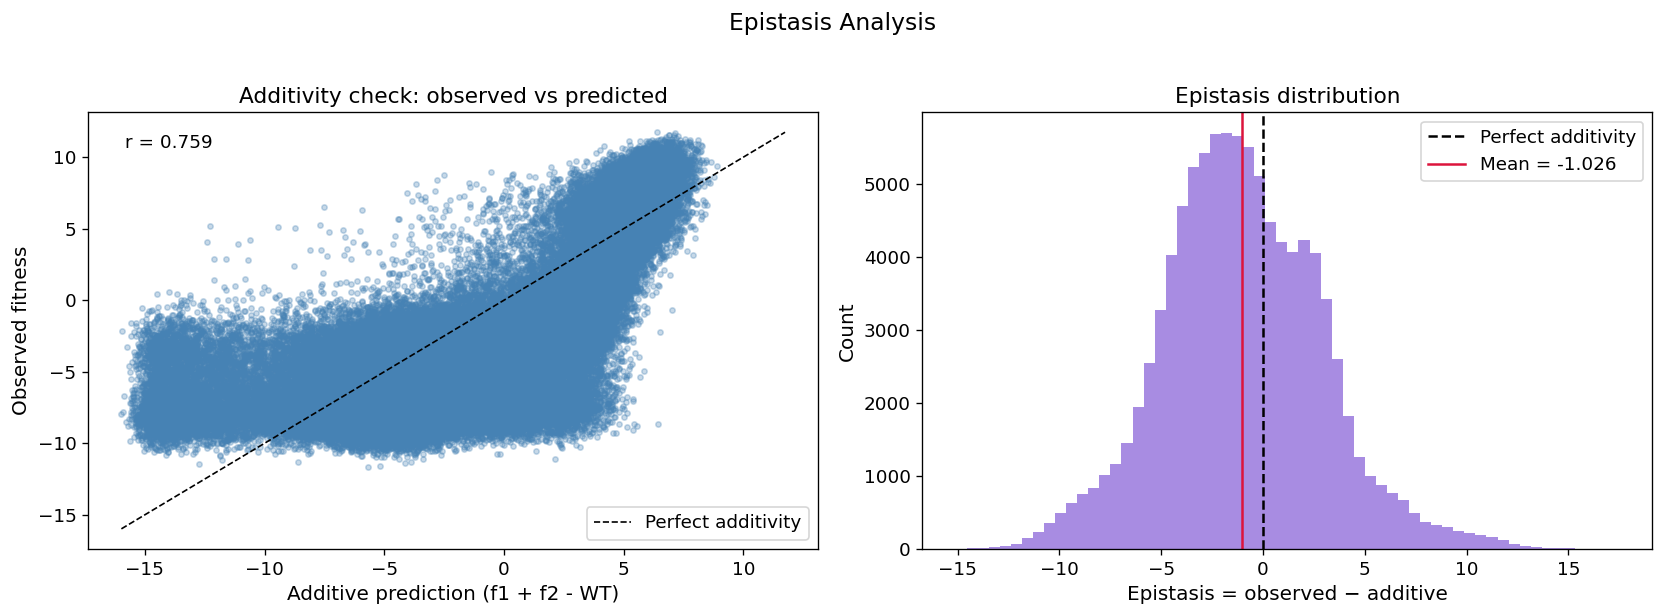

Mean epistasis:   -1.0263
Std epistasis:    3.9072
Fraction with positive epistasis (synergistic): 0.377


In [ ]:
# Build lookup: (pos, mut_aa) → ED1 fitness
ed1_lookup = {}
for _, row in df_ed1_flat.iterrows():
    key = (row['pos'], row['mut_aa'])
    ed1_lookup[key] = row['fitness']

# For each ED2 sequence, check if both singles are in ED1
epistasis_records = []
for _, row in df_ed2.iterrows():
    muts = row['parsed_muts']
    if len(muts) != 2 or pd.isna(row[METRIC_COL]):
        continue
    (p1, _, aa1), (p2, _, aa2) = muts
    f1 = ed1_lookup.get((p1, aa1))
    f2 = ed1_lookup.get((p2, aa2))
    if f1 is not None and f2 is not None:
        # Additive prediction: f1 + f2 - WT (since WT contributes twice otherwise)
        additive = f1 + f2 - WT_FITNESS
        observed = row[METRIC_COL]
        epistasis_records.append({
            'observed': observed,
            'additive': additive,
            'epistasis': observed - additive,
            'pos1': p1, 'aa1': aa1,
            'pos2': p2, 'aa2': aa2,
        })

df_epi = pd.DataFrame(epistasis_records)
print(f"ED2 sequences with both singles in ED1: {len(df_epi):,} / {len(df_ed2):,}")

if len(df_epi) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Observed vs additive
    ax = axes[0]
    ax.scatter(df_epi['additive'], df_epi['observed'], alpha=0.3, s=10, color='steelblue')
    lim = [min(df_epi[['observed', 'additive']].min()), max(df_epi[['observed', 'additive']].max())]
    ax.plot(lim, lim, 'k--', lw=1, label='Perfect additivity')
    ax.set_xlabel('Additive prediction (f1 + f2 - WT)')
    ax.set_ylabel('Observed fitness')
    ax.set_title('Additivity check: observed vs predicted')
    corr = df_epi[['observed', 'additive']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, va='top')
    ax.legend()

    # Epistasis distribution
    ax = axes[1]
    ax.hist(df_epi['epistasis'], bins=60, color='mediumpurple', alpha=0.8, edgecolor='none')
    ax.axvline(0, color='black', lw=1.5, linestyle='--', label='Perfect additivity')
    ax.axvline(df_epi['epistasis'].mean(), color='crimson', lw=1.5, linestyle='-',
               label=f'Mean = {df_epi["epistasis"].mean():.3f}')
    ax.set_xlabel('Epistasis = observed − additive')
    ax.set_ylabel('Count')
    ax.set_title('Epistasis distribution')
    ax.legend()

    plt.suptitle('Epistasis Analysis', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Mean epistasis:   {df_epi['epistasis'].mean():.4f}")
    print(f"Std epistasis:    {df_epi['epistasis'].std():.4f}")
    print(f"Fraction with positive epistasis (synergistic): {(df_epi['epistasis'] > 0).mean():.3f}")
else:
    print("No ED2 sequences found where both singles exist in ED1 — cannot estimate epistasis.")

### Higher-order epistasis (ED3, ED4, ED5 vs ED1 additive baseline)

ED3: 148,061 / 148,061 sequences have all singles in ED1
ED4: 26,441 / 26,441 sequences have all singles in ED1
ED5: 2,418 / 2,418 sequences have all singles in ED1

ED3 epistasis summary:
  Mean:              0.0964
  Std:               5.8620
  Fraction positive: 0.441

ED4 epistasis summary:
  Mean:              2.1692
  Std:               7.5620
  Fraction positive: 0.566

ED5 epistasis summary:
  Mean:              4.6378
  Std:               8.3352
  Fraction positive: 0.684


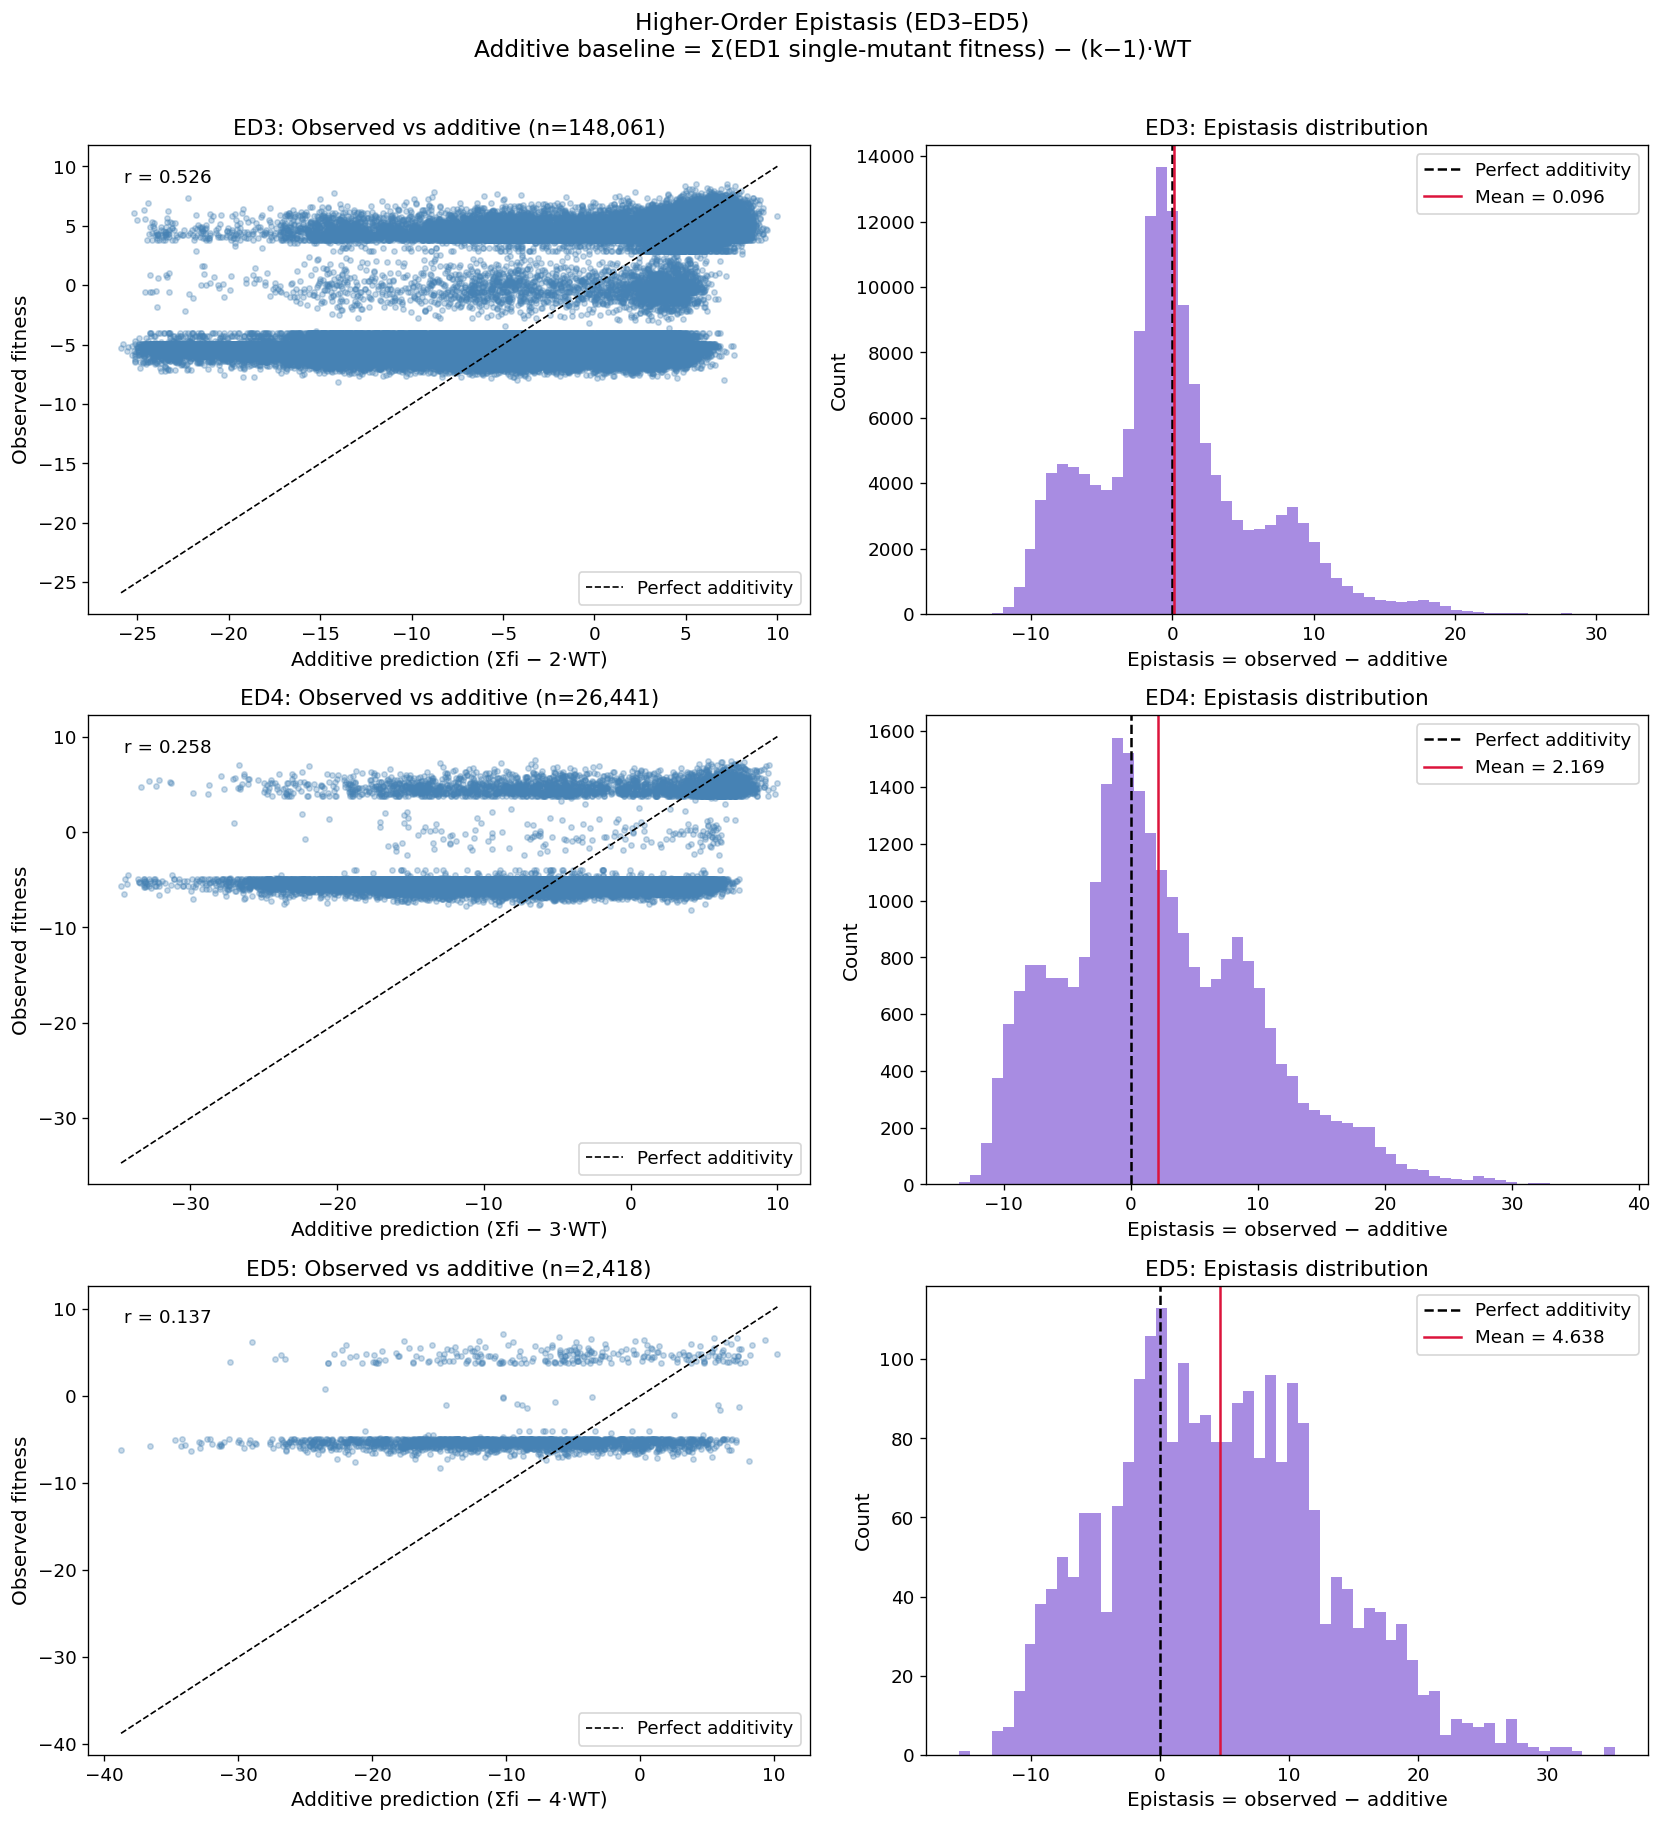

In [21]:
# Higher-order epistasis: ED3, ED4, ED5 vs additive prediction from ED1 singles
# Additive model for k mutations: sum(f_i) - (k-1)*WT_FITNESS
# (each single contributes its own deviation from WT; the k-1 subtractions remove the k-1 extra WT baselines)

higher_ed_dfs = {
    3: df[df[NUM_MUT_COL] == 3].copy(),
    4: df[df[NUM_MUT_COL] == 4].copy(),
    5: df[df[NUM_MUT_COL] == 5].copy(),
}

higher_epi_results = {}
for ed, df_edn in higher_ed_dfs.items():
    records = []
    for _, row in df_edn.iterrows():
        muts = row['parsed_muts']
        if len(muts) != ed or pd.isna(row[METRIC_COL]):
            continue
        fitnesses = [ed1_lookup.get((p, aa)) for (p, _, aa) in muts]
        if all(f is not None for f in fitnesses):
            additive = sum(fitnesses) - (ed - 1) * WT_FITNESS
            observed = row[METRIC_COL]
            record = {'observed': observed, 'additive': additive, 'epistasis': observed - additive}
            for i, (p, _, aa) in enumerate(muts, 1):
                record[f'pos{i}'] = p
                record[f'aa{i}'] = aa
            records.append(record)
    higher_epi_results[ed] = pd.DataFrame(records)
    print(f"ED{ed}: {len(records):,} / {len(df_edn):,} sequences have all singles in ED1")

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for row_idx, ed in enumerate([3, 4, 5]):
    df_epi_n = higher_epi_results[ed]
    ax_scatter, ax_hist = axes[row_idx]

    if len(df_epi_n) == 0:
        for ax in (ax_scatter, ax_hist):
            ax.text(0.5, 0.5, f'No ED{ed} sequences\nwith all singles in ED1',
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.axis('off')
        continue

    # Observed vs additive
    ax_scatter.scatter(df_epi_n['additive'], df_epi_n['observed'], alpha=0.3, s=10, color='steelblue')
    lim = [min(df_epi_n[['observed', 'additive']].min()), max(df_epi_n[['observed', 'additive']].max())]
    ax_scatter.plot(lim, lim, 'k--', lw=1, label='Perfect additivity')
    ax_scatter.set_xlabel(f'Additive prediction (Σfi − {ed-1}·WT)')
    ax_scatter.set_ylabel('Observed fitness')
    ax_scatter.set_title(f'ED{ed}: Observed vs additive (n={len(df_epi_n):,})')
    corr = df_epi_n[['observed', 'additive']].corr().iloc[0, 1]
    ax_scatter.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax_scatter.transAxes, va='top')
    ax_scatter.legend()

    # Epistasis distribution
    ax_hist.hist(df_epi_n['epistasis'], bins=60, color='mediumpurple', alpha=0.8, edgecolor='none')
    ax_hist.axvline(0, color='black', lw=1.5, linestyle='--', label='Perfect additivity')
    ax_hist.axvline(df_epi_n['epistasis'].mean(), color='crimson', lw=1.5, linestyle='-',
                    label=f'Mean = {df_epi_n["epistasis"].mean():.3f}')
    ax_hist.set_xlabel('Epistasis = observed − additive')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title(f'ED{ed}: Epistasis distribution')
    ax_hist.legend()

    print(f"\nED{ed} epistasis summary:")
    print(f"  Mean:              {df_epi_n['epistasis'].mean():.4f}")
    print(f"  Std:               {df_epi_n['epistasis'].std():.4f}")
    print(f"  Fraction positive: {(df_epi_n['epistasis'] > 0).mean():.3f}")

plt.suptitle('Higher-Order Epistasis (ED3–ED5)\nAdditive baseline = Σ(ED1 single-mutant fitness) − (k−1)·WT',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Higher-order epistasis — ED2-based decompositions (ED3/4/5)

For each higher-order sequence we try **all ways** to split its mutations into one or more ED2 pairs plus ED1 singletons, then average the additive predictions over all valid partitions.

Schemes tested:
| ED | Scheme |
|---|---|
| ED3 | ED2 + ED1 |
| ED4 | ED2 + ED2 |
| ED4 | ED2 + ED1 + ED1 |
| ED5 | ED2 + ED2 + ED1 |
| ED5 | ED2 + ED1 + ED1 + ED1 |

Additive formula for _m_ groups: `Σ fitness(group_i) − (m−1)·WT`

ED2 pair lookup: 97,977 unique mutation pairs
ED3 [ED2+ED1               ]: 148,060 / 148,061 sequences covered
ED4 [ED2+ED2               ]: 26,441 / 26,441 sequences covered
ED4 [ED2+ED1+ED1           ]: 26,441 / 26,441 sequences covered
ED5 [ED2+ED2+ED1           ]:  2,418 /  2,418 sequences covered
ED5 [ED2+ED1+ED1+ED1       ]:  2,418 /  2,418 sequences covered


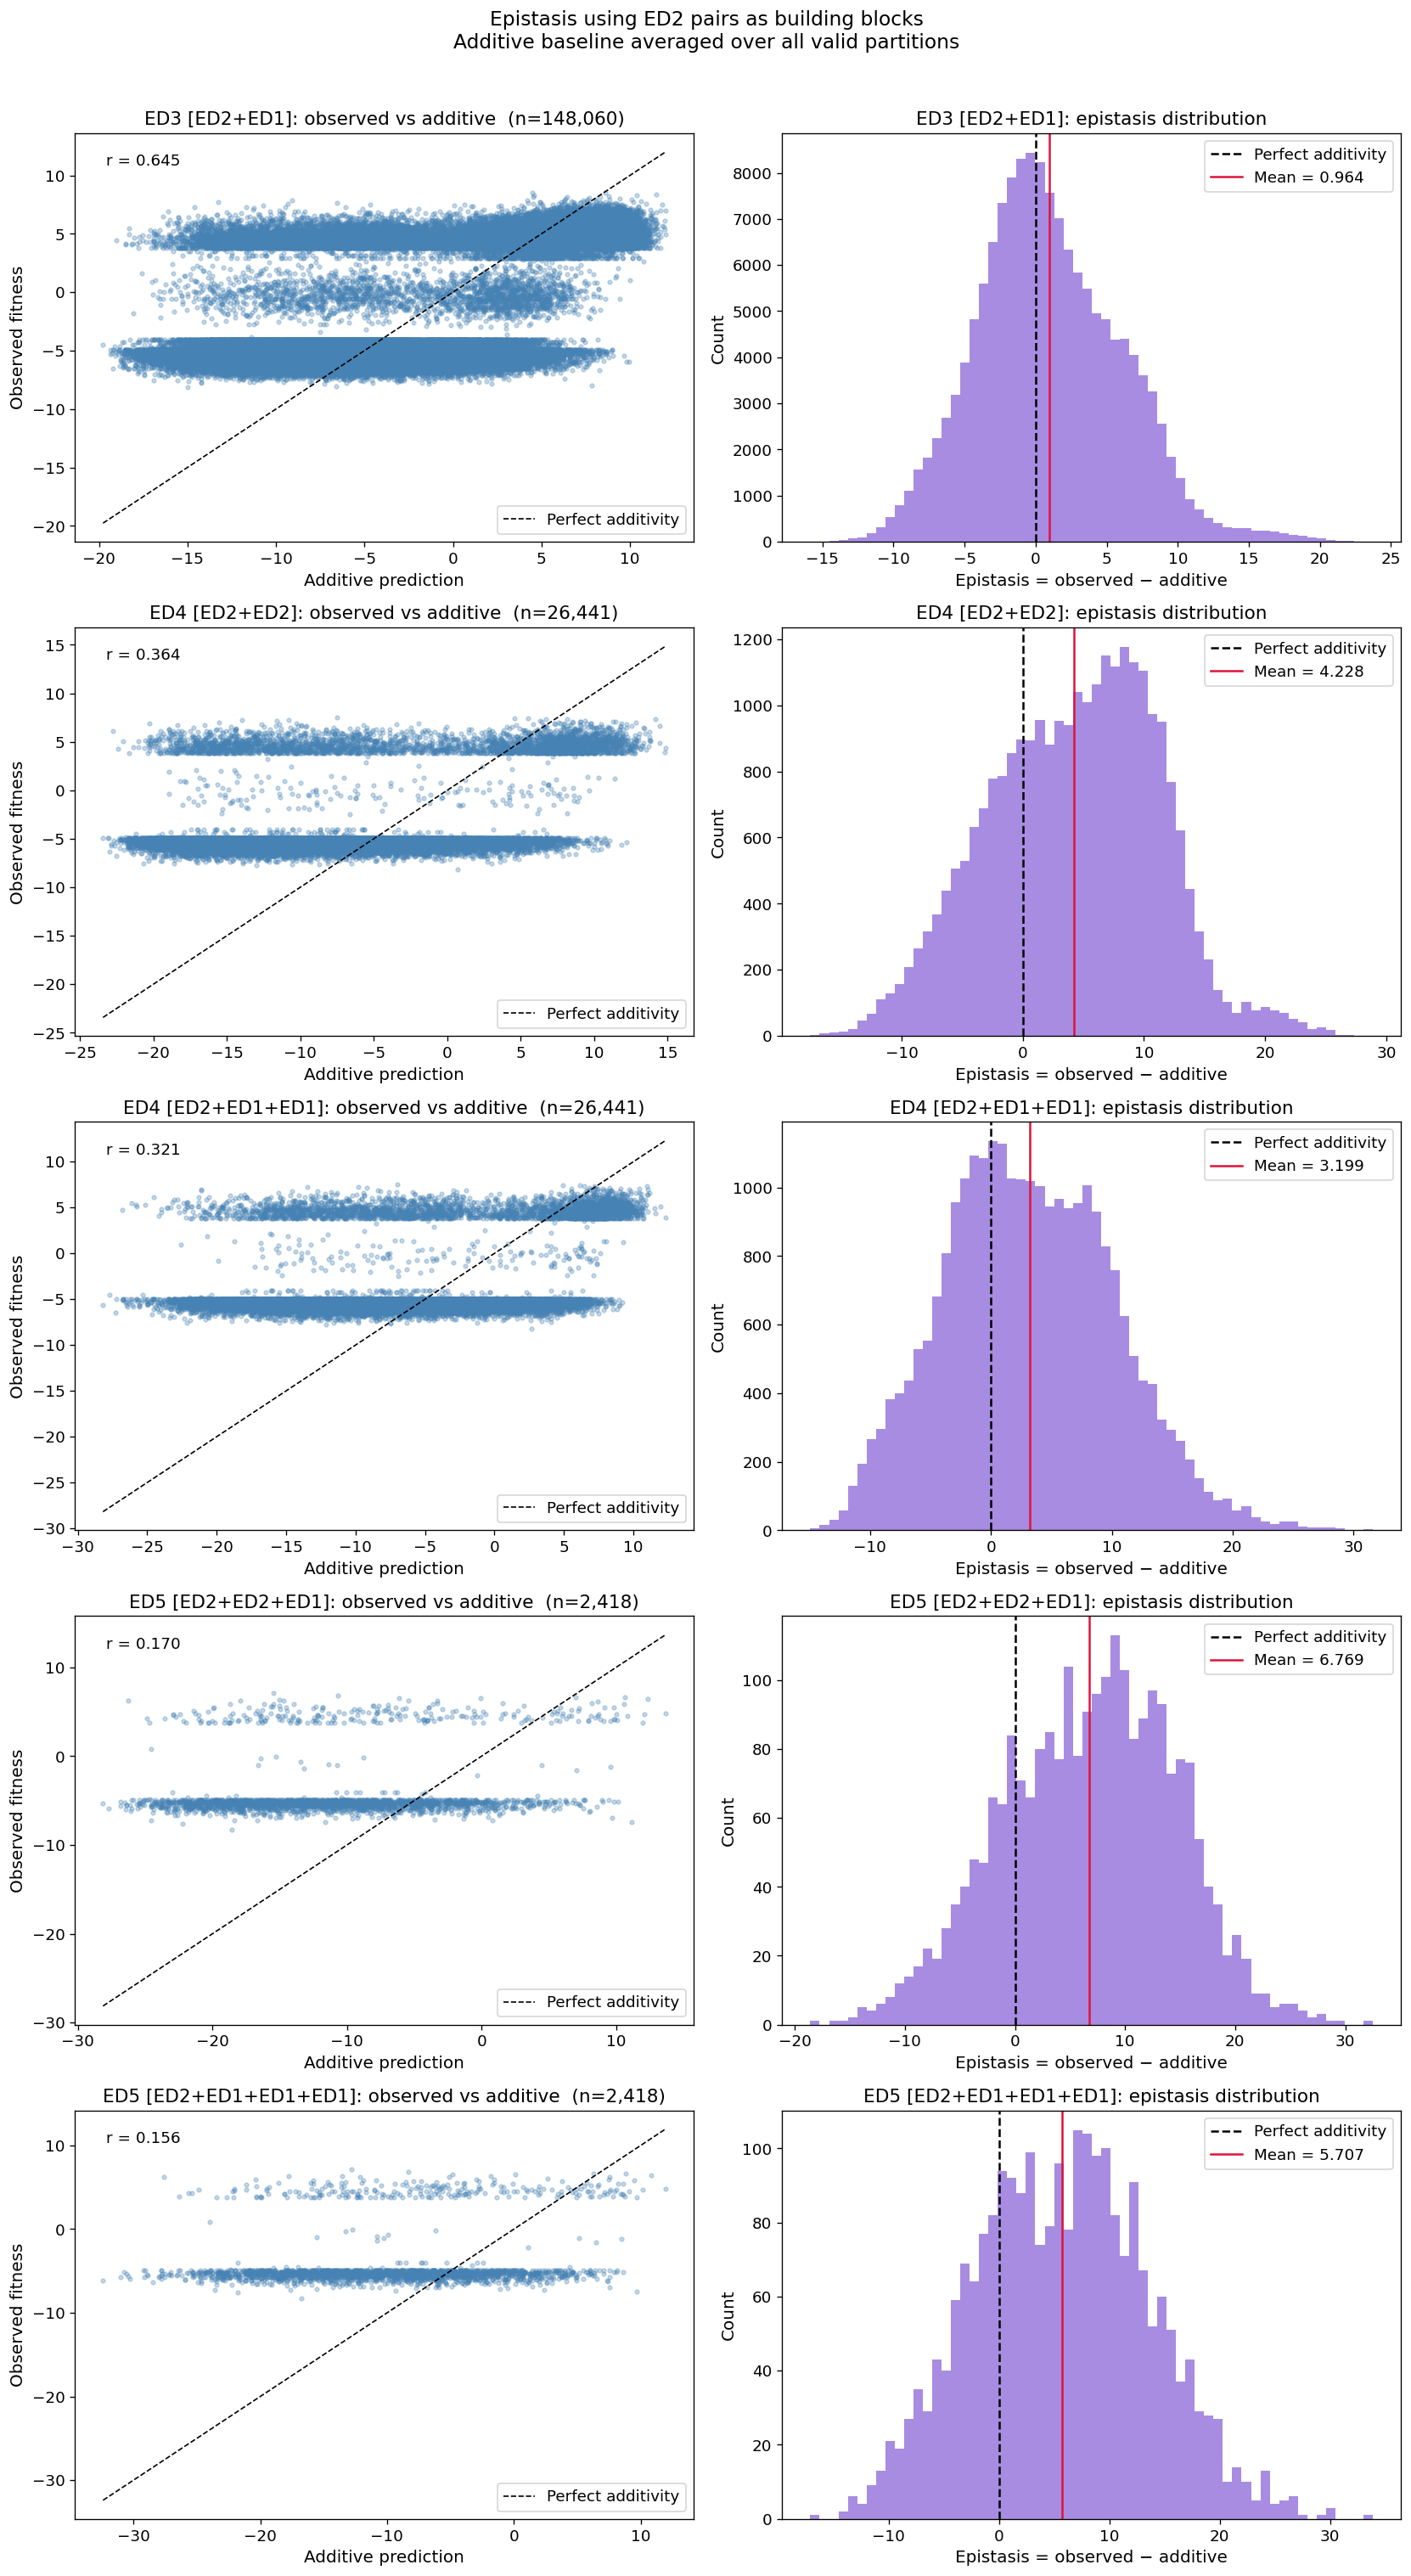


Summary:
  ED3 [ED2+ED1               ]  n=148,060  mean=+0.9641  std=5.1200  frac_pos=0.543
  ED4 [ED2+ED2               ]  n=26,441  mean=+4.2278  std=6.9559  frac_pos=0.715
  ED4 [ED2+ED1+ED1           ]  n=26,441  mean=+3.1989  std=7.0116  frac_pos=0.650
  ED5 [ED2+ED2+ED1           ]  n= 2,418  mean=+6.7695  std=7.7897  frac_pos=0.789
  ED5 [ED2+ED1+ED1+ED1       ]  n= 2,418  mean=+5.7070  std=7.9276  frac_pos=0.746


In [23]:
from itertools import combinations

# ── Build ED2 pair lookup: frozenset({(pos, mut_aa), ...}) → mean fitness ─────
ed2_pair_lookup = {}
for _, row in df_ed2.iterrows():
    muts = row['parsed_muts']
    if len(muts) != 2 or pd.isna(row[METRIC_COL]):
        continue
    key = frozenset((p, aa) for (p, _, aa) in muts)
    ed2_pair_lookup.setdefault(key, []).append(row[METRIC_COL])
ed2_pair_lookup = {k: np.mean(v) for k, v in ed2_pair_lookup.items()}
print(f"ED2 pair lookup: {len(ed2_pair_lookup):,} unique mutation pairs")

# ── Helpers ───────────────────────────────────────────────────────────────────
def partition_pairs(indices):
    """All ways to partition a list of indices into unordered pairs."""
    if not indices:
        yield []
        return
    first, rest = indices[0], indices[1:]
    for i, partner in enumerate(rest):
        remaining = rest[:i] + rest[i+1:]
        for sub in partition_pairs(remaining):
            yield [(first, partner)] + sub

def additive_predictions(mut_keys, n_pairs):
    """
    Return list of valid additive predictions for a given sequence,
    trying all ways to assign n_pairs ED2-groups + rest as ED1 singletons.
    mut_keys: list of (pos, mut_aa).
    """
    n = len(mut_keys)
    preds = []
    for pair_pool in combinations(range(n), 2 * n_pairs):
        singleton_idx = [i for i in range(n) if i not in pair_pool]
        for pairs in partition_pairs(list(pair_pool)):
            pair_fs   = [ed2_pair_lookup.get(frozenset([mut_keys[i], mut_keys[j]])) for i, j in pairs]
            single_fs = [ed1_lookup.get(mut_keys[i]) for i in singleton_idx]
            all_f = pair_fs + single_fs
            if all(f is not None for f in all_f):
                n_groups = n_pairs + len(singleton_idx)
                preds.append(sum(all_f) - (n_groups - 1) * WT_FITNESS)
    return preds

# ── Run all schemes ───────────────────────────────────────────────────────────
schemes = [
    (3, 1, 'ED2+ED1'),
    (4, 2, 'ED2+ED2'),
    (4, 1, 'ED2+ED1+ED1'),
    (5, 2, 'ED2+ED2+ED1'),
    (5, 1, 'ED2+ED1+ED1+ED1'),
]

epi2_results = {}
for ed, n_pairs, label in schemes:
    df_edn = df[df[NUM_MUT_COL] == ed]
    records = []
    for _, row in df_edn.iterrows():
        muts = row['parsed_muts']
        if len(muts) != ed or pd.isna(row[METRIC_COL]):
            continue
        mut_keys = [(p, aa) for (p, _, aa) in muts]
        preds = additive_predictions(mut_keys, n_pairs)
        if preds:
            additive = np.mean(preds)
            records.append({
                'observed':     row[METRIC_COL],
                'additive':     additive,
                'epistasis':    row[METRIC_COL] - additive,
                'n_partitions': len(preds),
            })
    epi2_results[(ed, label)] = pd.DataFrame(records)
    print(f"ED{ed} [{label:<22s}]: {len(records):>6,} / {len(df_edn):>6,} sequences covered")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(schemes), 2, figsize=(14, 5 * len(schemes)))

for row_idx, (ed, n_pairs, label) in enumerate(schemes):
    df_res = epi2_results[(ed, label)]
    ax_s, ax_h = axes[row_idx]

    if len(df_res) == 0:
        for ax in (ax_s, ax_h):
            ax.text(0.5, 0.5, 'No sequences covered\n(all components absent from lookups)',
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
        continue

    # Scatter: observed vs additive
    ax_s.scatter(df_res['additive'], df_res['observed'], alpha=0.3, s=8, color='steelblue')
    lim = [min(df_res[['observed', 'additive']].min()), max(df_res[['observed', 'additive']].max())]
    ax_s.plot(lim, lim, 'k--', lw=1, label='Perfect additivity')
    corr = df_res[['observed', 'additive']].corr().iloc[0, 1]
    ax_s.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax_s.transAxes, va='top')
    ax_s.set_xlabel('Additive prediction')
    ax_s.set_ylabel('Observed fitness')
    ax_s.set_title(f'ED{ed} [{label}]: observed vs additive  (n={len(df_res):,})')
    ax_s.legend()

    # Histogram: epistasis distribution
    mean_e = df_res['epistasis'].mean()
    ax_h.hist(df_res['epistasis'], bins=60, color='mediumpurple', alpha=0.8, edgecolor='none')
    ax_h.axvline(0,      color='black',  lw=1.5, linestyle='--', label='Perfect additivity')
    ax_h.axvline(mean_e, color='crimson', lw=1.5, label=f'Mean = {mean_e:.3f}')
    ax_h.set_xlabel('Epistasis = observed − additive')
    ax_h.set_ylabel('Count')
    ax_h.set_title(f'ED{ed} [{label}]: epistasis distribution')
    ax_h.legend()

plt.suptitle(
    'Epistasis using ED2 pairs as building blocks\n'
    'Additive baseline averaged over all valid partitions',
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()

print("\nSummary:")
for ed, n_pairs, label in schemes:
    df_res = epi2_results[(ed, label)]
    if len(df_res) > 0:
        print(f"  ED{ed} [{label:<22s}]  n={len(df_res):>6,}  "
              f"mean={df_res['epistasis'].mean():+.4f}  "
              f"std={df_res['epistasis'].std():.4f}  "
              f"frac_pos={(df_res['epistasis'] > 0).mean():.3f}")

## 7. Baseline-Oriented Summary

Distillation of the above into concrete baseline strategies.

In [15]:
# ── Ranked list of mutations for baseline sampling ────────────────────────────
# Per (pos, mut_aa): mean fitness, fraction above WT, count
mut_stats = df_muts.groupby(['pos', 'mut_aa']).agg(
    count=('fitness', 'count'),
    mean_fitness=('fitness', 'mean'),
    frac_above_wt=('above_wt', 'mean'),
).reset_index()

# Filter to mutations with at least a few observations
mut_stats_filtered = mut_stats[mut_stats['count'] >= 3].copy()

print("=" * 60)
print("BASELINE SAMPLING POOLS")
print("=" * 60)

print("\n[B1] Uniform over observed mutations (your original idea)")
print(f"Pool size: {len(df_muts):,} mutation events from {len(df):,} sequences")
print("Strategy: sample k positions uniformly, then for each position")
print("          sample a mutant AA from observed variants at that position")

print("\n[B2] Fitness-weighted sampling from ED1 mutations")
above_wt_muts = df_ed1_flat[df_ed1_flat['above_wt']].copy()
print(f"Pool size: {len(above_wt_muts)} single mutations above WT")
print("Strategy: sample from these with weight ∝ fitness")

print("\n[B3] Greedy: always pick top-k single mutations")
top_k = df_ed1_flat.nlargest(10, 'fitness')[['pos', 'wt_aa', 'mut_aa', 'fitness']]
print("Top 10 single mutations:")
print(top_k.to_string(index=False))
print("Strategy: always include these k mutations (potentially incompatible positions)") 

print("\n[B4] Position-aware: sample only from 'permissive' positions")
permissive = pos_stats_ed1[pos_stats_ed1['frac_above_wt'] > 0.5].sort_values('frac_above_wt', ascending=False)
print(f"Positions where >50% of single mutants are above WT: {list(permissive['pos'].values)}")
print("Strategy: restrict sampling to these positions")

print("\n[B5] Frequency-proportional position sampling")
pos_freq_norm = pos_freq / pos_freq.sum()
print("Strategy: sample positions with probability ∝ how often they appear in dataset")
print("(mirrors the DMS experimental design rather than biology)")

BASELINE SAMPLING POOLS

[B1] Uniform over observed mutations (your original idea)
Pool size: 758,447 mutation events from 275,354 sequences
Strategy: sample k positions uniformly, then for each position
          sample a mutant AA from observed variants at that position

[B2] Fitness-weighted sampling from ED1 mutations
Pool size: 120 single mutations above WT
Strategy: sample from these with weight ∝ fitness

[B3] Greedy: always pick top-k single mutations
Top 10 single mutations:
 pos wt_aa mut_aa  fitness
   7     V      P 7.254119
   7     V      A 7.014238
  17     V      A 6.839072
   7     V      E 6.706891
   8     S      E 6.696253
   8     S      G 6.549619
   8     S      D 6.474300
   7     V      Q 6.455669
   1     M      R 6.411182
  21     F      M 6.368614
Strategy: always include these k mutations (potentially incompatible positions)

[B4] Position-aware: sample only from 'permissive' positions
Positions where >50% of single mutants are above WT: [np.int64(7), np.in

Position-level summary (ED1):
pos_label  n_variants  mean_fitness  frac_above_wt  best_fitness  worst_fitness  classification
     1(H)          19     -0.766126       0.052632      5.255270      -5.314814 very intolerant
     2(M)          19      4.384500       0.315789      6.411182      -4.129366      intolerant
     3(S)          19      1.892913       0.105263      6.292865      -3.923758 very intolerant
     4(M)          19      2.807110       0.105263      5.796088      -3.953180 very intolerant
     5(Q)          19     -2.404165       0.000000      4.256125      -4.620036 very intolerant
     6(Q)          19      3.300250       0.157895      5.929277      -4.939968 very intolerant
     7(V)          19     -1.187753       0.052632      5.225563      -5.357802 very intolerant
     8(V)          19      6.063489       0.947368      7.254119       5.049559 very permissive
     9(S)          19      5.339662       0.684211      6.696253       2.240608      permissive
    10(A) 

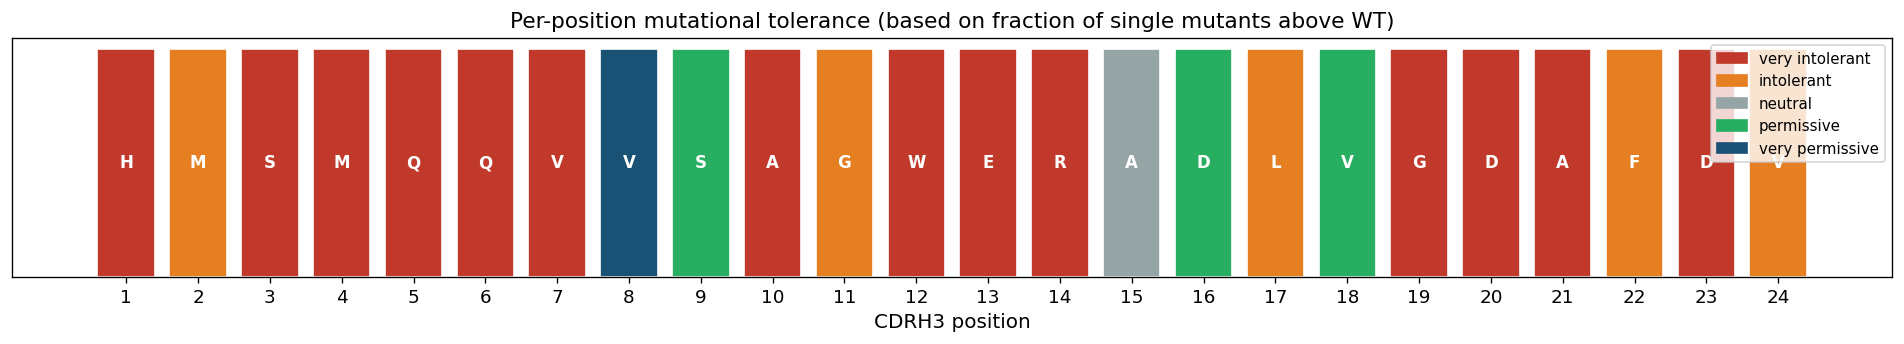

In [16]:
# ── Summary table of per-position characteristics ────────────────────────────
summary = pos_stats_ed1.copy()
summary['wt_aa'] = [WT_CDRH3[p] for p in summary['pos']]
summary['pos_label'] = [f"{p+1}({WT_CDRH3[p]})" for p in summary['pos']]
summary['classification'] = pd.cut(
    summary['frac_above_wt'],
    bins=[-0.01, 0.2, 0.4, 0.6, 0.8, 1.01],
    labels=['very intolerant', 'intolerant', 'neutral', 'permissive', 'very permissive']
)

print("Position-level summary (ED1):")
display_cols = ['pos_label', 'n_variants', 'mean_fitness', 'frac_above_wt', 'best_fitness', 'worst_fitness', 'classification']
print(summary[display_cols].to_string(index=False))

# Visual classification
fig, ax = plt.subplots(figsize=(16, 3))
cmap_class = {'very intolerant': '#c0392b', 'intolerant': '#e67e22',
              'neutral': '#95a5a6', 'permissive': '#27ae60', 'very permissive': '#1a5276'}
for _, row in summary.iterrows():
    color = cmap_class.get(str(row['classification']), 'gray')
    ax.bar(row['pos'], 1, color=color, edgecolor='white')
    ax.text(row['pos'], 0.5, row['wt_aa'], ha='center', va='center', fontsize=10, color='white', fontweight='bold')

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in cmap_class.items()]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
ax.set_xticks(range(CDRH3_LEN))
ax.set_xticklabels([str(i+1) for i in range(CDRH3_LEN)])
ax.set_yticks([])
ax.set_xlabel('CDRH3 position')
ax.set_title('Per-position mutational tolerance (based on fraction of single mutants above WT)')
plt.tight_layout()
plt.show()